# Lab Day 1 — Xây dựng mạng nơ-ron và thí nghiệm huấn luyện (Forest CoverType)

Notebook này nằm trong `submission_<MSSV>/code/` và chạy được từ đầu đến cuối bằng *Restart & Run All*.
Mọi module (`data.py`, `model.py`, `optimizer.py`, `train.py`, `plots.py`, `results_table.py`) nằm cùng thư mục.

- Kết quả ghi vào `../results/<exp_id>.json`, ảnh vào `../figures/<exp_id>.png`, bảng vào `../experiments.xlsx`.
- Mọi lựa chọn cấu hình dùng **val**. Tập **eval** chỉ được dùng ở Part 4, cho baseline và cấu hình cuối cùng.
- Mỗi thí nghiệm: **dự đoán trước** (viết trước khi chạy) → đổi **một** yếu tố → chạy → **đối chiếu** với ngưỡng nhiễu 2σ của baseline.

In [3]:
# ===== (Chỉ khi chạy trên Colab) lấy repo + mã nguồn, chuyển vào submission_<MSSV>/code =====
# Trước khi chạy: Runtime -> Change runtime type -> T4 GPU, rồi tải file submission_<MSSV>_code.zip lên /content
# (biểu tượng thư mục ở thanh bên trái -> Upload). Chạy cục bộ từ submission_<MSSV>/code/ thì ô này không làm gì.
import os, sys, glob, zipfile, subprocess
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not os.path.exists("data.py"):
    REPO_URL = "https://github.com/VinUni-AI20k/K4-Track4-Day1-Neuralnetwork.git"
    REPO_DIR = "/content/K4-Track4-Day1-Neuralnetwork"
    if not os.path.exists(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    zips = sorted(glob.glob("/content/submission_*.zip"))
    assert zips, "Chưa thấy /content/submission_*_code.zip: hãy tải file zip mã nguồn lên /content rồi chạy lại ô này"
    with zipfile.ZipFile(zips[-1]) as z:
        z.extractall(REPO_DIR)                      # tạo <repo>/submission_<MSSV>/code/*.py
    code_dir = sorted(glob.glob(f"{REPO_DIR}/submission_*/code"))[-1]
    os.chdir(code_dir); sys.path.insert(0, code_dir)
print("thư mục làm việc:", os.getcwd())

thư mục làm việc: /content/K4-Track4-Day1-Neuralnetwork/submission_MSSV/code


In [4]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, math, time, tempfile, subprocess
import numpy as np, pandas as pd, torch
from IPython.display import Image, display

REPO_ROOT = os.environ.get("LAB_REPO_ROOT", "../..")   # thư mục gốc repo (chứa data/ và scripts/)
OUT_DIR   = os.environ.get("LAB_OUT_DIR", "..")        # = submission_<MSSV>/
EPOCHS    = int(os.environ.get("LAB_EPOCHS", 20))      # số epoch chung cho mọi thí nghiệm (20 theo README)
USE_CACHE = True   # True: thí nghiệm đã có ../results/<exp_id>.json với ĐÚNG cấu hình thì nạp lại, không huấn luyện lại
                   # (phòng khi Colab ngắt kết nối). Đặt False để huấn luyện lại tất cả.

FIG_DIR, RES_DIR = f"{OUT_DIR}/figures", f"{OUT_DIR}/results"
os.makedirs(FIG_DIR, exist_ok=True); os.makedirs(RES_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| python", sys.version.split()[0], "| device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0), "| bf16 supported:", torch.cuda.is_bf16_supported())
else:
    print("Không có GPU: chạy trên CPU,", torch.get_num_threads(), "luồng. peak_mem_MB sẽ để trống.")

from data import prepare_data, iterate_batches
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import (DEFAULT_CFG, set_seed, evaluate, predict, compute_loss, run_experiment,
                   final_eval, run_official_eval)
from plots import plot_run, plot_compare, plot_lr_sweep, plot_curve, plot_confusion
from results_table import save_result, load_result, to_row, sort_rows, write_xlsx

torch 2.11.0+cu130 | python 3.13.15 | device: cuda
GPU: Tesla T4 | bf16 supported: True


## Part 0 — Dữ liệu

Chia train/eval bằng `scripts/split_data.py` (theo `split_metadata.csv`, không tự chia lại). Sau đó tách 20% của train làm
validation (phân tầng, seed 42), chuẩn hoá 10 cột số bằng thống kê của **phần train còn lại**, đưa mọi thứ lên `device` một lần.

In [5]:
env = {**os.environ, "PYTHONIOENCODING": "utf-8"}
out = subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, env=env,
                     capture_output=True, text=True, encoding="utf-8")
print(out.stdout); assert out.returncode == 0, out.stderr

data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")
assert data["X_tr"].shape == (371_847, 54) and data["X_val"].shape == (92_962, 54) and data["X_eval"].shape == (116_203, 54)
assert data["y_tr"].dtype == torch.int64 and data["X_tr"].dtype == torch.float32

train: X (464809, 54) float32, y (464809,) int64, nhãn 0..6 -> data/processed/train.npz
eval : X (116203, 54) float32, y (116203,) int64, nhãn 0..6 -> data/processed/eval.npz

lớp   train(%)   eval(%)
  0    36.461    36.460
  1    48.760    48.760
  2     6.154     6.154
  3     0.473     0.472
  4     1.634     1.634
  5     2.989     2.989
  6     3.530     3.530

đoán luôn lớp đa số (lớp 1) cho accuracy trên eval = 0.4876

train (sau khi tách val): (371847, 54)   val: (92962, 54)   eval: (116203, 54)   device: cuda
luôn đoán lớp đa số (lớp 1) -> accuracy trên val = 0.4876


In [6]:
# Tỉ lệ lớp ở ba tập (chỉ để kiểm tra phép chia phân tầng; không dùng nhãn eval cho việc gì khác trước Part 4)
prop = pd.DataFrame({name: np.bincount(data[k].cpu().numpy(), minlength=7) / len(data[k]) * 100
                     for name, k in [("train %", "y_tr"), ("val %", "y_val"), ("eval %", "y_eval")]})
prop.index.name = "lớp"
print(prop.round(3).to_string())

num = data["X_tr"][:, :10]
print("\n10 cột số trên train sau chuẩn hoá:  |mean| lớn nhất = %.2e   std nhỏ nhất/lớn nhất = %.4f / %.4f"
      % (num.mean(0).abs().max().item(), num.std(0).min().item(), num.std(0).max().item()))
print("44 cột nhị phân giữ nguyên: giá trị ∈", sorted(torch.unique(data["X_tr"][:, 10:]).tolist()))
print("Mốc thấp nhất — luôn đoán lớp đa số (lớp %d): val accuracy = %.4f"
      % (data["majority_class"], data["majority_val_acc"]))

     train %   val %  eval %
lớp                         
0     36.461  36.460  36.460
1     48.760  48.760  48.760
2      6.154   6.154   6.154
3      0.473   0.472   0.472
4      1.634   1.634   1.634
5      2.989   2.989   2.989
6      3.530   3.530   3.530

10 cột số trên train sau chuẩn hoá:  |mean| lớn nhất = 3.61e-07   std nhỏ nhất/lớn nhất = 1.0000 / 1.0000
44 cột nhị phân giữ nguyên: giá trị ∈ [0.0, 1.0]
Mốc thấp nhất — luôn đoán lớp đa số (lớp 1): val accuracy = 0.4876


**Vì sao chỉ tính mean/std trên train?** Nếu tính trên cả val/eval thì thống kê của dữ liệu "chưa thấy" đã rò rỉ vào đầu vào của
mô hình, khiến điểm val/eval lạc quan hơn thực tế. Trong `data.py`, `fit_standardizer` chỉ nhận `X_tr` (sau khi tách val);
`X_eval` chỉ đi qua `apply_standardizer` và không được đọc ở bất kỳ bước chọn cấu hình nào.

## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu

`M-base` = `54 → 256 → 128 → 7`, ReLU, **47 879 tham số**, logits `(B, 7)`, không softmax trong model, khởi tạo He (gọi tường minh
`kaiming_normal_`, bias = 0).

In [7]:
# 1b. Số tham số và shape
for hidden, n in EXPECTED_PARAMS.items():
    assert count_params(MLP(hidden=hidden)) == n
    print(f"hidden={hidden}: {n:,} tham số  OK")

set_seed(1)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
assert count_params(model) == EXPECTED_PARAMS[(256, 128)] == 47_879
print(model)

h = torch.randn(8, 54, device=device)
print("\nx", tuple(h.shape))
for layer in model.net:
    h = layer(h)
    print(f"  -> {layer.__class__.__name__:8s} {tuple(h.shape)}")
assert h.shape == (8, 7)

hidden=(256, 128): 47,879 tham số  OK
hidden=(512, 256): 161,287 tham số  OK
hidden=(256, 128, 64): 55,687 tham số  OK
MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)

x (8, 54)
  -> Linear   (8, 256)
  -> ReLU     (8, 256)
  -> Linear   (8, 128)
  -> ReLU     (8, 128)
  -> Linear   (8, 7)


In [8]:
# 1c-1. Loss bước 0 trên val (eval mode), so với ln 7
ln7 = math.log(7)
ev0 = evaluate(model, data["X_val"], data["y_val"], "ce")
logit_std = activation_stats(model, data["X_val"][:4096])[-1]
print(f"loss bước 0 (He, seed 1) = {ev0['loss']:.4f}   ln 7 = {ln7:.4f}   chênh = {ev0['loss'] - ln7:+.4f}")
print(f"độ lệch chuẩn của logit ở bước 0 = {logit_std:.3f}")

# đối chứng: cùng kiến trúc nhưng lớp cuối khởi tạo rất nhỏ -> logit ≈ 0 -> loss phải ≈ ln 7
set_seed(1); m_small = MLP(init="he").to(device)
with torch.no_grad(): m_small.net[-1].weight.mul_(0.01)
print(f"lớp cuối nhân 0.01      -> loss bước 0 = {evaluate(m_small, data['X_val'], data['y_val'])['loss']:.4f}")

# kiểm tra chéo macro-F1 tự tính với sklearn
from sklearn.metrics import f1_score
p = predict(model, data["X_val"]).cpu().numpy()
assert abs(f1_score(data["y_val"].cpu().numpy(), p, average="macro") - ev0["macro_f1"]) < 1e-9
print("macro-F1 tự tính (từ ma trận nhầm lẫn) khớp sklearn.metrics.f1_score")

loss bước 0 (He, seed 1) = 2.2691   ln 7 = 1.9459   chênh = +0.3232
độ lệch chuẩn của logit ở bước 0 = 0.577
lớp cuối nhân 0.01      -> loss bước 0 = 1.9477
macro-F1 tự tính (từ ma trận nhầm lẫn) khớp sklearn.metrics.f1_score


nhãn của 20 mẫu: [0, 0, 0, 0, 6, 4, 0, 1, 1, 0, 0, 0, 0, 1, 6, 0, 0, 0, 0, 5]
loss: bước 1 = 2.4803 | bước 50 = 0.0002 | bước 300 = 0.000063 | accuracy trên 20 mẫu = 1.00


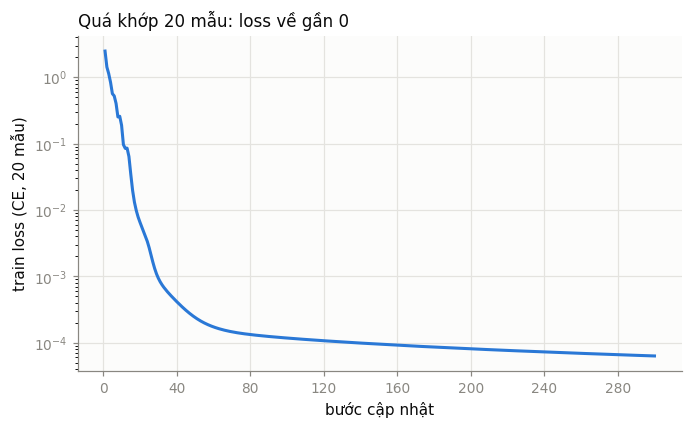

In [9]:
# 1c-2. Quá khớp 20 mẫu: tắt dropout, huấn luyện full-batch vài trăm bước -> loss phải về gần 0
set_seed(1)
m = MLP(dropout=0.0, init="he").to(device)
xb, yb = data["X_tr"][:20], data["y_tr"][:20]
opt = build_optimizer("sgd_momentum", m.parameters(), lr=0.1)
losses = []
m.train()
for step in range(300):
    loss = compute_loss(m(xb), yb, "ce")
    opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
    losses.append(loss.item())
acc20 = (predict(m, xb) == yb).float().mean().item()
print("nhãn của 20 mẫu:", yb.tolist())
print(f"loss: bước 1 = {losses[0]:.4f} | bước 50 = {losses[49]:.4f} | bước 300 = {losses[-1]:.6f} | accuracy trên 20 mẫu = {acc20:.2f}")
assert losses[-1] < 0.01 and acc20 == 1.0
plot_curve(losses, f"{FIG_DIR}/check_overfit20.png", "bước cập nhật", "train loss (CE, 20 mẫu)",
           "Quá khớp 20 mẫu: loss về gần 0", logy=True)
display(Image(filename=f"{FIG_DIR}/check_overfit20.png"))

In [10]:
# 1d. Gradient có chảy tới mọi tham số không?
set_seed(1)
m = MLP(init="he").to(device)
xb, yb = next(iterate_batches(data["X_tr"], data["y_tr"], 512, torch.Generator(device=device).manual_seed(1)))
compute_loss(m(xb), yb, "ce").backward()
names = ["W1", "b1", "W2", "b2", "W3", "b3"]
for name, p_ in zip(names, m.parameters()):
    assert p_.grad is not None and p_.grad.norm().item() > 0, name
    print(f"{name}: shape {str(tuple(p_.shape)):12s} ‖grad‖ = {p_.grad.norm().item():.4f}")
print("chuẩn toàn cục =", round(clip_gradients(m.parameters(), None), 4), "(clip_gradients với max_norm=None chỉ đo, không cắt)")

W1: shape (256, 54)    ‖grad‖ = 0.4863
b1: shape (256,)       ‖grad‖ = 0.3410
W2: shape (128, 256)   ‖grad‖ = 1.9100
b2: shape (128,)       ‖grad‖ = 0.4332
W3: shape (7, 128)     ‖grad‖ = 1.8918
b3: shape (7,)         ‖grad‖ = 0.5653
chuẩn toàn cục = 2.8437 (clip_gradients với max_norm=None chỉ đo, không cắt)


**Nhận xét Part 1 (sau khi chạy):**
- **Số tham số / shape:** `M-base` = 47 879, `M-wide` = 161 287, `M-deep` = 55 687 (khớp bảng quy định); logits `(8, 7)`.
- **Loss bước 0 = 2,2691, cao hơn ln 7 = 1,9459 là 0,3232.** Đây không phải lỗi code mà là hệ quả của việc áp dụng He cho **cả lớp ra**:
  Var[W₃] = 2/128 làm logit ở bước 0 có độ lệch chuẩn 0,577, tức softmax không đều và CE trung bình lớn hơn ln 7. Đối chứng: nhân W₃
  với 0,01 (logit ≈ 0) thì loss = 1,9477 ≈ ln 7. Giá trị này còn phụ thuộc seed (seed 2: 1,9782; seed 3: 1,9005, xem bảng baseline) và
  cách khởi tạo (mục 3.7: `zeros` cho đúng 1,94591; `default` 1,983; `xavier` 2,022). Tôi giữ He cho mọi lớp như baseline quy định.
- **Quá khớp 20 mẫu:** loss 2,4803 → 0,0002 sau 50 bước → 6,3e-5 sau 300 bước, accuracy 100% trên 20 mẫu → pipeline (nhãn, loss,
  `zero_grad`, optimizer) hoạt động đúng.
- **Gradient chảy:** cả 6 tham số có ‖grad‖ > 0 (W₁ 0,486; b₁ 0,341; W₂ 1,910; b₂ 0,433; W₃ 1,892; b₃ 0,565); chuẩn toàn cục 2,8437
  đúng bằng căn của tổng bình phương 6 chuẩn trên.

## Part 2 — Pipeline và baseline

`run_experiment(cfg, data)` (trong `train.py`) nhận một dict cấu hình và trả về lịch sử + tóm tắt. Mỗi epoch ghi: train loss
(đo ở `eval()` trên một tập con **cố định** 50 000 mẫu train), val loss / accuracy / macro-F1, `grad_norm` trung bình và lớn nhất
(**trước** clip), thời gian vòng huấn luyện; ngoài ra có loss bước 0, best epoch theo val loss, cờ `diverged`.

Hàm `run()` dưới đây bọc `run_experiment`: lưu `results/<exp_id>.json`, vẽ `figures/<exp_id>.png`, và ghi nhớ kết quả để lập bảng.

In [11]:
RESULTS = {}                      # exp_id -> result (theo thứ tự chạy); mỗi phần tử là một dòng của experiments.xlsx
NOTES = {}                        # exp_id -> ghi chú cho cột notes
BASE_CFG = {**DEFAULT_CFG, "epochs": EPOCHS}     # lr sẽ được chọn bằng val ở ô dưới

def _norm(cfg):                   # dạng so sánh được của cfg (tuple -> list)
    return json.loads(json.dumps({**DEFAULT_CFG, **cfg}))

def run(over, note="", need_state=False, verbose=False):
    # Chạy (hoặc nạp từ cache) một thí nghiệm = BASE_CFG + các khoá trong `over`.
    cfg = {**BASE_CFG, **over}
    cached = load_result(cfg["exp_id"], RES_DIR) if (USE_CACHE and not need_state) else None
    if cached is not None and _norm(cached["cfg"]) == _norm(cfg):
        result = {**cached, "best_state": None}
        src = "cache"
    else:
        result = run_experiment(cfg, data, verbose=verbose)
        save_result(result, RES_DIR)
        src = "train"
    plot_run(result, f"{FIG_DIR}/{cfg['exp_id']}.png")
    RESULTS[cfg["exp_id"]] = result
    if note: NOTES[cfg["exp_id"]] = note
    s = result["summary"]
    if s["diverged"]:
        print(f"[{src}] {cfg['exp_id']:24s} DIVERGED sau {s['n_steps']} bước (step0 {s['step0_loss']:.4f})")
    else:
        print(f"[{src}] {cfg['exp_id']:24s} step0 {s['step0_loss']:.4f} | best ep {s['best_epoch']:2d} val_loss {s['best_val_loss']:.4f}"
              f" acc {s['val_acc']:.4f} macroF1 {s['val_macro_f1']:.4f} | train {s['final_train_loss']:.4f} | {s['time_per_epoch_s']:.1f}s/ep")
    return result

def f1_of(r):                     # val macro-F1 ở best epoch; -inf nếu diverged
    v = r["summary"]["val_macro_f1"]
    return -math.inf if (r["summary"]["diverged"] or v is None) else v

def table(ids, extra=()):
    # Bảng tóm tắt các thí nghiệm; nếu đã có baseline nhiều seed thì thêm chênh lệch so với trung bình baseline và 2σ.
    rows = []
    for i in ids:
        c, s = RESULTS[i]["cfg"], RESULTS[i]["summary"]
        row = dict(exp_id=i, lr=c["lr"], step0=s["step0_loss"], best_val_loss=s["best_val_loss"], best_ep=s["best_epoch"],
                   val_acc=s["val_acc"], val_macro_f1=s["val_macro_f1"])
        if "BASE_F1_MEAN" in globals() and s["val_macro_f1"] is not None:
            d = s["val_macro_f1"] - BASE_F1_MEAN
            row["dF1_vs_base"] = d
            row["vượt_2σ"] = "Có" if abs(d) > NOISE_F1 else "Không"
        row["gap_val-train"] = None if s["final_val_loss"] is None or s["final_train_loss"] is None else s["final_val_loss"] - s["final_train_loss"]
        row["s/epoch"] = s["time_per_epoch_s"]
        row["diverged"] = "Y" if s["diverged"] else "N"
        for k in extra: row[k] = s.get(k, c.get(k))
        rows.append(row)
    df = pd.DataFrame(rows).set_index("exp_id")
    with pd.option_context("display.width", 250, "display.max_columns", 30, "display.float_format", "{:.4f}".format):
        print(df.to_string())
    return df

### 2a. Chọn `lr` cho baseline (bằng val)

Baseline: SGD + momentum 0,9, CE, He, batch 512, 20 epoch, không dropout / clip, FP32. Thử `lr ∈ {0,01; 0,03; 0,1; 0,3}` với seed 1 và
chọn giá trị có **val macro-F1** cao nhất. Bốn lần chạy này cũng là các dòng "SGD+momentum" của chủ đề bộ tối ưu (nhóm `optimizer`).

**Dự đoán trước:** lr 0,01 quá nhỏ cho 20 epoch nên còn chưa khớp (val loss cao nhất, vẫn đang giảm ở epoch cuối); lr 0,1 sẽ tốt hơn 0,03;
lr 0,3 với momentum 0,9 (bước hiệu dụng ≈ lr/(1−μ) = 3) có thể dao động, val loss nhấp nhô và có thể kém hơn 0,1.

In [12]:
SGDM_LRS = [0.01, 0.03, 0.1, 0.3]
sgdm_runs = [run(dict(exp_id=f"opt-sgdm-lr{lr:g}", group="optimizer", lr=lr,
                      description=f"SGD+momentum, lr={lr:g} (dò lr cho baseline)"),
                 note="Dò lr của baseline bằng val; cấu hình còn lại giống baseline.") for lr in SGDM_LRS]
table([r["cfg"]["exp_id"] for r in sgdm_runs])
best_sgdm = max(sgdm_runs, key=f1_of)
BASE_CFG["lr"] = best_sgdm["cfg"]["lr"]
print(f"\n=> lr baseline chọn bằng val macro-F1: {BASE_CFG['lr']:g}")

[train] opt-sgdm-lr0.01          step0 2.2691 | best ep 20 val_loss 0.3110 acc 0.8747 macroF1 0.7613 | train 0.3026 | 1.3s/ep
[train] opt-sgdm-lr0.03          step0 2.2691 | best ep 20 val_loss 0.2660 acc 0.8921 macroF1 0.8170 | train 0.2504 | 1.3s/ep
[train] opt-sgdm-lr0.1           step0 2.2691 | best ep 18 val_loss 0.2379 acc 0.9054 macroF1 0.8390 | train 0.2222 | 1.3s/ep
[train] opt-sgdm-lr0.3           step0 2.2691 | best ep 19 val_loss 0.2318 acc 0.9090 macroF1 0.8573 | train 0.2078 | 1.3s/ep
                    lr  step0  best_val_loss  best_ep  val_acc  val_macro_f1  gap_val-train  s/epoch diverged
exp_id                                                                                                       
opt-sgdm-lr0.01 0.0100 2.2691         0.3110       20   0.8747        0.7613         0.0084   1.3131        N
opt-sgdm-lr0.03 0.0300 2.2691         0.2660       20   0.8921        0.8170         0.0155   1.2984        N
opt-sgdm-lr0.1  0.1000 2.2691         0.2379       18   

### 2b. Baseline với 3 seed và độ nhiễu

Chạy baseline ở lr vừa chọn với seed 1, 2, 3. Độ lệch chuẩn mẫu giữa các seed cho ngưỡng nhiễu **2σ**: mọi chênh lệch nhỏ hơn 2σ
không được coi là bằng chứng. (Seed đổi cả khởi tạo lẫn thứ tự xáo lô; phép tách val giữ nguyên seed 42.)

  [base-s1] epoch  1/20  train 0.4383  val 0.4404  acc 0.8127  f1 0.6037  gnorm 0.379  1.3s
  [base-s1] epoch  2/20  train 0.3793  val 0.3852  acc 0.8383  f1 0.7190  gnorm 0.369  1.2s
  [base-s1] epoch  3/20  train 0.3564  val 0.3625  acc 0.8464  f1 0.7494  gnorm 0.365  1.4s
  [base-s1] epoch  4/20  train 0.3207  val 0.3310  acc 0.8650  f1 0.7807  gnorm 0.367  1.5s
  [base-s1] epoch  5/20  train 0.2961  val 0.3070  acc 0.8748  f1 0.7968  gnorm 0.359  1.2s
  [base-s1] epoch  6/20  train 0.2910  val 0.3032  acc 0.8760  f1 0.8039  gnorm 0.359  1.2s
  [base-s1] epoch  7/20  train 0.2649  val 0.2770  acc 0.8860  f1 0.8116  gnorm 0.355  1.3s
  [base-s1] epoch  8/20  train 0.2699  val 0.2842  acc 0.8847  f1 0.8152  gnorm 0.357  1.4s
  [base-s1] epoch  9/20  train 0.2528  val 0.2722  acc 0.8899  f1 0.8163  gnorm 0.355  1.2s
  [base-s1] epoch 10/20  train 0.2540  val 0.2702  acc 0.8899  f1 0.8217  gnorm 0.352  1.3s
  [base-s1] epoch 11/20  train 0.2455  val 0.2638  acc 0.8944  f1 0.8415  gnorm 

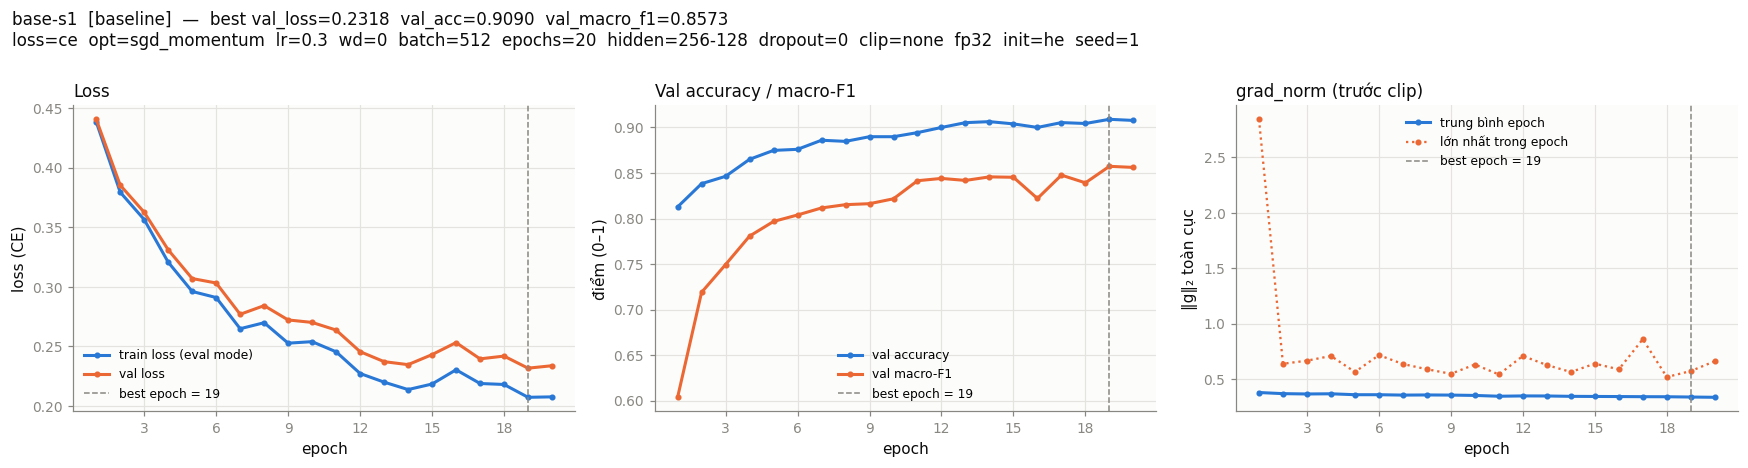

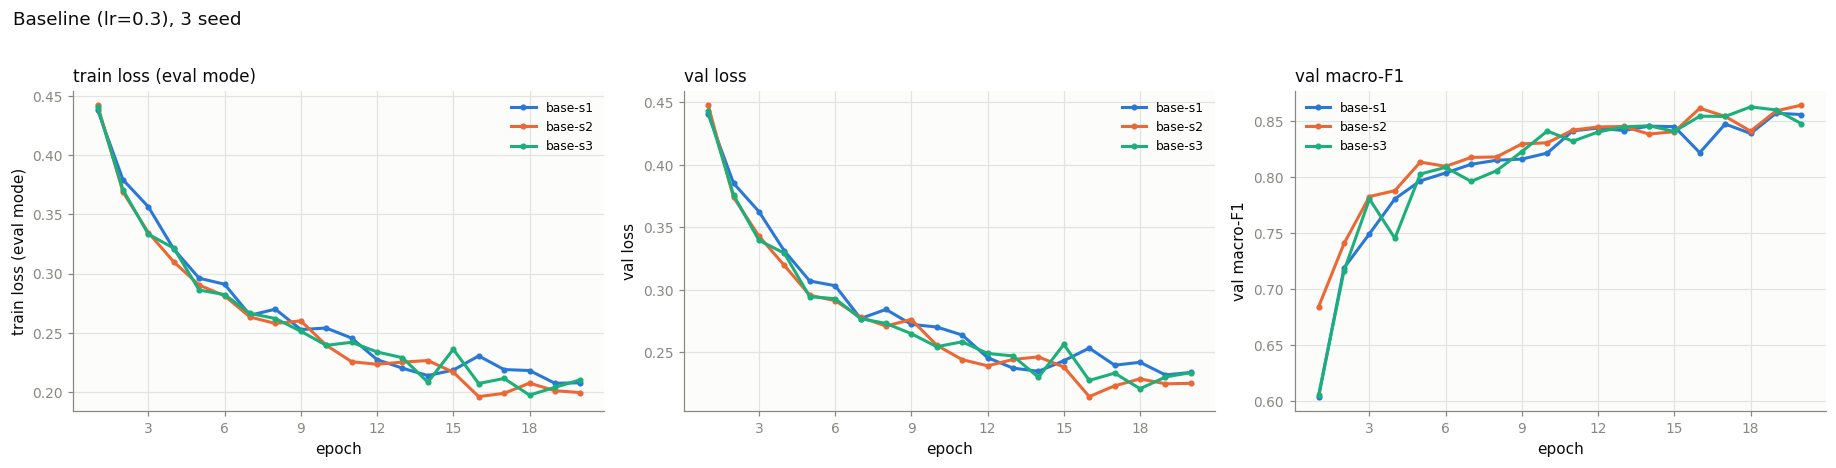

In [13]:
BASE_SEEDS = [1, 2, 3]
base_runs = [run(dict(exp_id=f"base-s{s}", group="baseline", seed=s, description=f"Baseline M-base, seed {s}"),
                 need_state=(s == 1), verbose=(s == 1)) for s in BASE_SEEDS]
BASE = RESULTS["base-s1"]

f1s  = np.array([r["summary"]["val_macro_f1"] for r in base_runs])
accs = np.array([r["summary"]["val_acc"] for r in base_runs])
vls  = np.array([r["summary"]["best_val_loss"] for r in base_runs])
BASE_F1_MEAN, BASE_ACC_MEAN = f1s.mean(), accs.mean()
NOISE_F1, NOISE_ACC = 2 * f1s.std(ddof=1), 2 * accs.std(ddof=1)
print(f"\nval macro-F1 : {f1s.round(4)}  TB = {f1s.mean():.4f}  σ = {f1s.std(ddof=1):.4f}  2σ = {NOISE_F1:.4f}")
print(f"val accuracy : {accs.round(4)}  TB = {accs.mean():.4f}  σ = {accs.std(ddof=1):.4f}  2σ = {NOISE_ACC:.4f}")
print(f"best val loss: {vls.round(4)}  TB = {vls.mean():.4f}  σ = {vls.std(ddof=1):.4f}")
print(f"mốc 'đoán đa số' trên val: accuracy = {data['majority_val_acc']:.4f}")
assert accs.min() > data["majority_val_acc"]
s = BASE["summary"]
print(f"\ngrad_norm theo BƯỚC của base-s1 (trước clip): trung vị = {s['grad_norm_p50']:.3f}  p90 = {s['grad_norm_p90']:.3f}  max = {s['grad_norm_max']:.3f}")
table([r["cfg"]["exp_id"] for r in base_runs])
plot_compare(base_runs, ["train_loss", "val_loss", "val_macro_f1"], f"{FIG_DIR}/compare_baseline.png",
             f"Baseline (lr={BASE_CFG['lr']:g}), 3 seed")
display(Image(filename=f"{FIG_DIR}/base-s1.png")); display(Image(filename=f"{FIG_DIR}/compare_baseline.png"))

**Nhận xét baseline (sau khi chạy):**
- **Chọn lr:** val macro-F1 tăng đơn điệu theo lr: 0,7613 (0,01) → 0,8170 (0,03) → 0,8390 (0,1) → **0,8573 (0,3)**, nên chọn lr = 0,3.
  Dự đoán "0,3 có thể kém 0,1 vì dao động" **sai** về kết quả cuối, nhưng đúng về hình dạng: đường val của lr 0,3 nhấp nhô (macro-F1
  0,8453 → 0,8220 → 0,8477 ở epoch 15–17). **Hạn chế:** 0,3 nằm ở biên trên của lưới, lr tối ưu của SGD+momentum có thể còn cao hơn
  (lr = 3 thì sụp, xem 3.5; khoảng 0,3–3 chưa được dò).
- **Độ nhiễu (3 seed):** val macro-F1 = 0,8573 / 0,8618 / 0,8630 → TB **0,8607**, σ = 0,0030, **2σ = 0,0060**; val accuracy TB 0,9118
  (σ = 0,0027); best val loss TB 0,2224 (σ = 0,0088). σ ước lượng từ 3 seed nên chỉ là ước lượng thô.
- **Hình dạng đường cong:** train và val loss cùng giảm suốt 20 epoch, chưa đi ngang; khoảng cách val − train cuối cùng chỉ ≈ 0,026
  → mô hình **chưa khớp hết** là chính, quá khớp rất nhẹ. Best epoch (16–19) không phải epoch cuối là do nhiễu của lr cao chứ không
  phải do val loss quay đầu tăng.
- Val accuracy 0,909–0,914, cao hơn nhiều mốc "đoán đa số" 0,4876.
- `grad_norm` theo bước của `base-s1`: trung vị 0,347, p90 0,406, lớn nhất 2,84 (ở những bước đầu) → dùng để chọn `c` ở mục 3.5.

## Part 3 — Thí nghiệm

Quy ước chung: mỗi thí nghiệm = `BASE_CFG` (baseline seed 1) + **một** thay đổi; cùng phép tách val, cùng 20 epoch, cùng seed 1.
Cột `dF1_vs_base` = val macro-F1 − trung bình baseline (3 seed); `vượt_2σ` so |chênh| với ngưỡng nhiễu. Thí nghiệm nào đổi nhiều hơn
một yếu tố được ghi rõ trong `description`/`notes`.

### 3.1 Hàm mất mát — CE vs MSE (`loss-mse`)

MSE ở đây = `mean((logit − onehot)²)` trên **mọi phần tử** `(B×7)`, không có hệ số ½ (đúng như `nn.MSELoss`); logit thô, không softmax.

**Dự đoán trước:** MSE sẽ kém CE rõ rệt về macro-F1 sau 20 epoch ở cùng lr. Lý do: (1) gradient của MSE theo logit là `2(z − y)/(7B)`,
nhỏ hơn gradient `(softmax − y)/B` của CE khoảng một bậc (hệ số 2/7 và sai số bị chặn), nên cùng lr thì học chậm hơn; (2) với lớp hiếm,
MSE "hài lòng" khi đẩy logit về gần 0 cho mọi mẫu, còn CE phạt rất nặng khi xác suất lớp đúng nhỏ. Vì hai loss khác thang đo, chỉ so
accuracy / macro-F1 và tốc độ hội tụ, không so giá trị loss. `grad_norm` của MSE sẽ nhỏ hơn nhiều so với CE.

[train] loss-mse                 step0 0.6359 | best ep 20 val_loss 0.0274 acc 0.8803 macroF1 0.7726 | train 0.0265 | 1.4s/ep
             lr  step0  best_val_loss  best_ep  val_acc  val_macro_f1  dF1_vs_base vượt_2σ  gap_val-train  s/epoch diverged  grad_norm_p50
exp_id                                                                                                                                    
base-s1  0.3000 2.2691         0.2318       19   0.9090        0.8573      -0.0034   Không         0.0261   1.2905        N         0.3466
loss-mse 0.3000 0.6359         0.0274       20   0.8803        0.7726      -0.0881      Có         0.0009   1.4148        N         0.0653


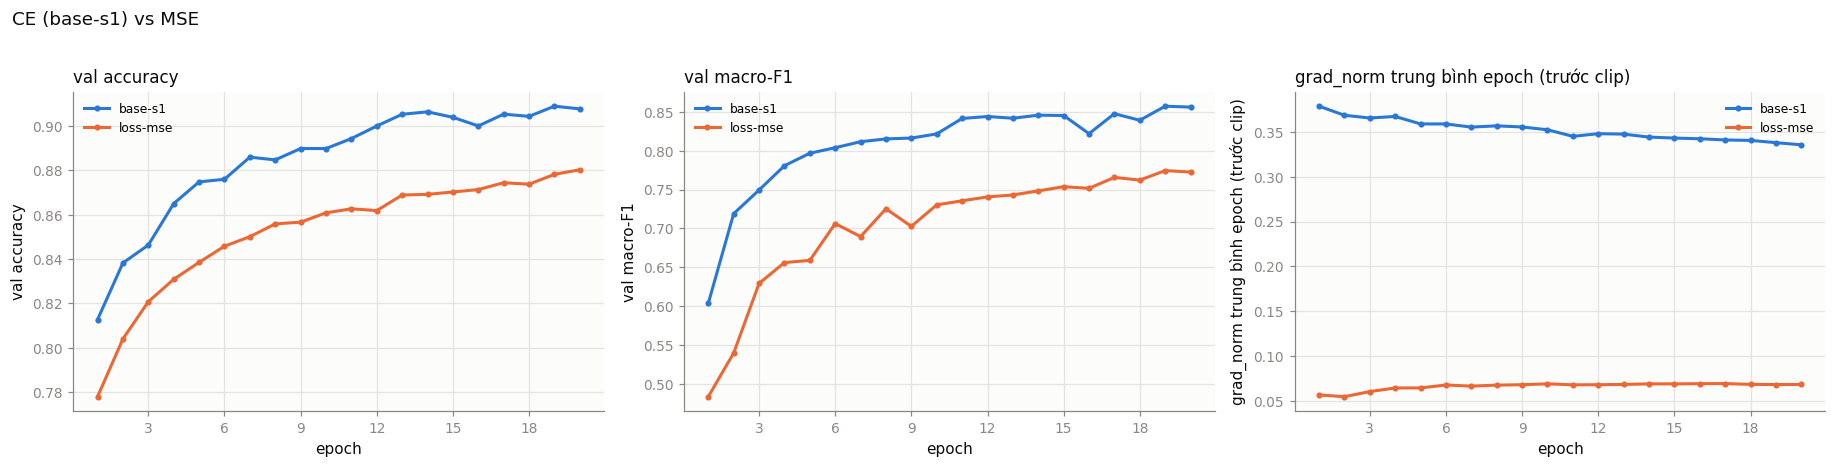

In [14]:
r_mse = run(dict(exp_id="loss-mse", group="loss", loss="mse", description="MSE trên one-hot thay cho CE"),
            note="MSE = mean((logit-onehot)^2) trên mọi phần tử (B x 7), không hệ số 1/2. Loss khác thang đo với CE: chỉ so acc/macro-F1.")
table(["base-s1", "loss-mse"], extra=("grad_norm_p50",))
plot_compare([BASE, r_mse], ["val_acc", "val_macro_f1", "grad_norm"], f"{FIG_DIR}/compare_loss.png", "CE (base-s1) vs MSE")
display(Image(filename=f"{FIG_DIR}/compare_loss.png"))

**Đối chiếu sau khi chạy — khớp dự đoán.**
- `loss-mse`: val macro-F1 **0,7726**, thấp hơn trung bình baseline 0,8607 là **−0,0881** (gấp ~15 lần ngưỡng 2σ = 0,0060); accuracy
  0,8803 so với 0,9090. Khoảng cách ở macro-F1 (−0,088) lớn gấp ba khoảng cách ở accuracy (−0,029) → phần thiệt nằm chủ yếu ở lớp hiếm.
- **Cơ chế:** trung vị `grad_norm` của MSE là 0,065, nhỏ hơn CE (0,347) khoảng 5,3 lần ở cùng lr → mỗi bước đi ngắn hơn, học chậm
  hơn; best epoch = 20 và macro-F1 vẫn đang tăng, tức MSE **chưa hội tụ** sau 20 epoch. Với CE, gradient theo logit là `softmax − y`,
  không bão hoà khi dự đoán sai nặng; với MSE trên logit, sai số của lớp hiếm bị pha loãng trong trung bình 7 phần tử.
- **Hạn chế:** lr không được dò lại cho MSE (chỉ đổi một yếu tố), nên một phần khoảng cách là do tối ưu chậm hơn chứ không chỉ do bản
  chất hàm mất mát; chỉ 1 seed. Hai loss khác thang đo (0,027 so với 0,23) nên không so trực tiếp giá trị loss.

### 3.2 Bộ tối ưu hoá (`opt-*`)

SGD, SGD+momentum (μ = 0,9), Adam, AdamW (β = (0,9; 0,999), ε = 1e-8; AdamW `weight_decay = 0,01`). Mỗi bộ được thử 3–4 giá trị lr cách
nhau ~3 lần, rồi so **ở lr tốt nhất của từng bộ** (theo val macro-F1). SGD không momentum được thử dải lr cao hơn vì bước hiệu dụng của
SGD+momentum ≈ lr/(1−μ) = 10·lr.

**Dự đoán trước:** (1) Khi mỗi bộ được chỉnh lr, Adam/AdamW sẽ nhỉnh hơn SGD+momentum một chút trong 20 epoch vì chia bước theo độ lớn
gradient từng tham số (các cột one-hot hiếm của Soil_Type có gradient thưa và nhỏ). (2) SGD thuần ở lr ≈ 10× lr của SGD+momentum sẽ cho
kết quả gần bằng SGD+momentum. (3) Adam nhạy với lr theo kiểu khác: 3e-3 có thể nhiễu, 1e-2 quá lớn (val loss nhấp nhô, kém hẳn), 3e-4 thì chậm. (4) AdamW với wd = 0,01 gần như
trùng Adam (suy giảm mỗi bước = lr·wd ≈ 1e-5, không đáng kể trên mạng chưa quá khớp); AdamW với wd = 0 phải **trùng khít** Adam.

In [15]:
OPT_GRID = {"sgd": [0.1, 0.3, 1.0, 3.0], "adam": [3e-4, 1e-3, 3e-3, 1e-2], "adamw": [3e-4, 1e-3, 3e-3, 1e-2]}
OPT_LABEL = {"sgd": "SGD", "sgd_momentum": "SGD+momentum", "adam": "Adam", "adamw": "AdamW"}
opt_runs = {"sgd_momentum": sgdm_runs}
for name, lrs in OPT_GRID.items():
    wd = 0.01 if name == "adamw" else 0.0
    opt_runs[name] = [run(dict(exp_id=f"opt-{name}-lr{lr:g}", group="optimizer", optimizer=name, lr=lr, weight_decay=wd,
                               description=f"{OPT_LABEL[name]}, lr={lr:g}" + (", weight_decay=0.01" if wd else "")),
                          note="betas=(0.9,0.999), eps=1e-8" if name != "sgd" else "momentum=0") for lr in lrs]
opt_runs = {k: opt_runs[k] for k in ["sgd", "sgd_momentum", "adam", "adamw"]}
table([r["cfg"]["exp_id"] for runs in opt_runs.values() for r in runs])

[train] opt-sgd-lr0.1            step0 2.2691 | best ep 18 val_loss 0.3475 acc 0.8580 macroF1 0.7551 | train 0.4364 | 1.2s/ep
[train] opt-sgd-lr0.3            step0 2.2691 | best ep 18 val_loss 0.2803 acc 0.8871 macroF1 0.8163 | train 0.3227 | 1.2s/ep
[train] opt-sgd-lr1              step0 2.2691 | best ep 18 val_loss 0.2522 acc 0.9000 macroF1 0.8344 | train 0.2784 | 1.3s/ep
[train] opt-sgd-lr3              step0 2.2691 | best ep 18 val_loss 0.3698 acc 0.8511 macroF1 0.6155 | train 0.3593 | 1.3s/ep
[train] opt-adam-lr0.0003        step0 2.2691 | best ep 20 val_loss 0.3135 acc 0.8727 macroF1 0.7877 | train 0.3042 | 1.4s/ep
[train] opt-adam-lr0.001         step0 2.2691 | best ep 19 val_loss 0.2494 acc 0.8993 macroF1 0.8456 | train 0.2362 | 1.4s/ep
[train] opt-adam-lr0.003         step0 2.2691 | best ep 19 val_loss 0.2145 acc 0.9153 macroF1 0.8677 | train 0.1883 | 1.4s/ep
[train] opt-adam-lr0.01          step0 2.2691 | best ep 20 val_loss 0.2153 acc 0.9168 macroF1 0.8639 | train 0.1860 | 

,lr,step0,best_val_loss,best_ep,val_acc,val_macro_f1,dF1_vs_base,vượt_2σ,gap_val-train,s/epoch,diverged
exp_id,,,,,,,,,,,
opt-sgd-lr0.1,0.1000,2.269062,0.347476,18,0.857985,0.755055,-0.105654,Có,0.007313,1.237858,N
opt-sgd-lr0.3,0.3000,2.269062,0.280293,18,0.887147,0.816342,-0.044367,Có,0.009903,1.248165,N
opt-sgd-lr1,1.0000,2.269062,0.252220,18,0.899970,0.834389,-0.026320,Có,0.022067,1.317014,N
opt-sgd-lr3,3.0000,2.269062,0.369805,18,0.851133,0.615479,-0.245229,Có,0.011105,1.263496,N
opt-sgdm-lr0.01,0.0100,2.269062,0.310973,20,0.874669,0.761253,-0.099455,Có,0.008417,1.313144,N
opt-sgdm-lr0.03,0.0300,2.269062,0.265973,20,0.892139,0.816958,-0.043750,Có,0.015528,1.298374,N
opt-sgdm-lr0.1,0.1000,2.269062,0.237924,18,0.905381,0.839036,-0.021673,Có,0.020369,1.283197,N
opt-sgdm-lr0.3,0.3000,2.269062,0.231815,19,0.908974,0.857346,-0.003362,Không,0.026117,1.285865,N
opt-adam-lr0.0003,0.0003,2.269062,0.313508,20,0.872658,0.787739,-0.072969,Có,0.009300,1.403455,N


Mỗi bộ tối ưu ở lr tốt nhất của nó (theo val macro-F1):
                      lr  step0  best_val_loss  best_ep  val_acc  val_macro_f1  dF1_vs_base vượt_2σ  gap_val-train  s/epoch diverged
exp_id                                                                                                                              
opt-sgd-lr1       1.0000 2.2691         0.2522       18   0.9000        0.8344      -0.0263      Có         0.0221   1.3170        N
opt-sgdm-lr0.3    0.3000 2.2691         0.2318       19   0.9090        0.8573      -0.0034   Không         0.0261   1.2859        N
opt-adam-lr0.003  0.0030 2.2691         0.2145       19   0.9153        0.8677       0.0070      Có         0.0277   1.4460        N
opt-adamw-lr0.003 0.0030 2.2691         0.2161       18   0.9130        0.8646       0.0039   Không         0.0209   1.4571        N
  SGD           độ nhạy với lr: macro-F1 từ 0.6155 đến 0.8344 (biên độ 0.2189), lr tốt nhất = 1
  SGD+momentum  độ nhạy với lr: macro-F1 từ 0.7613

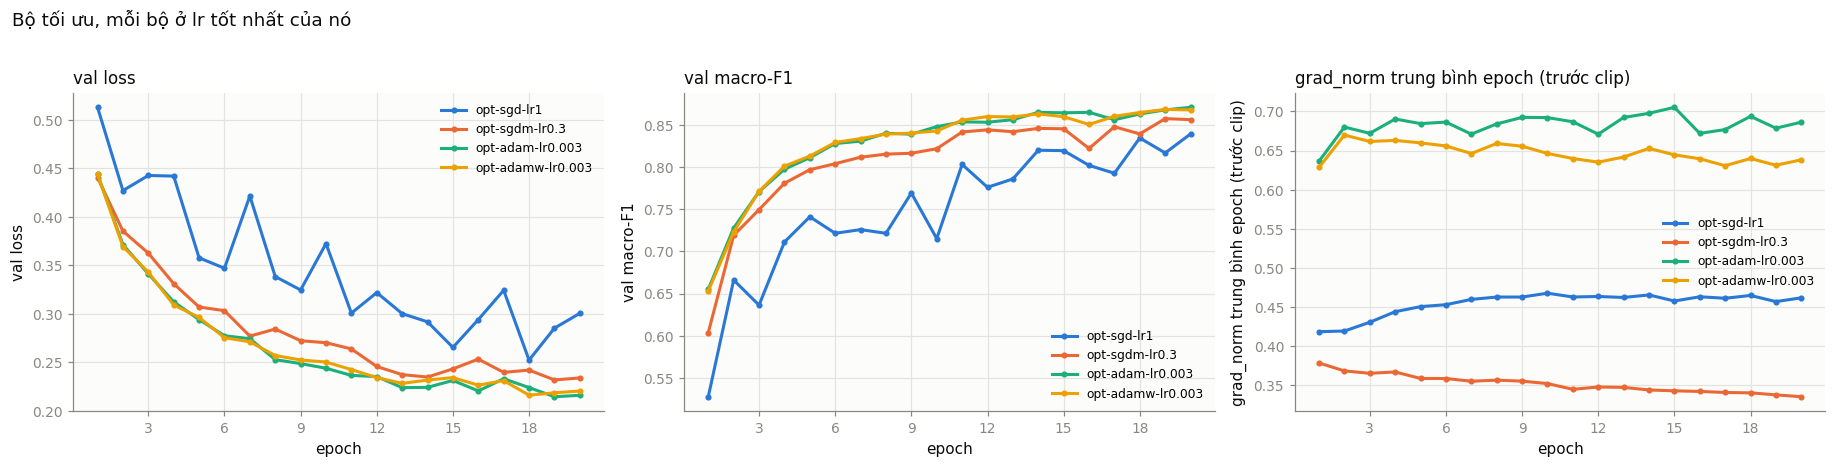

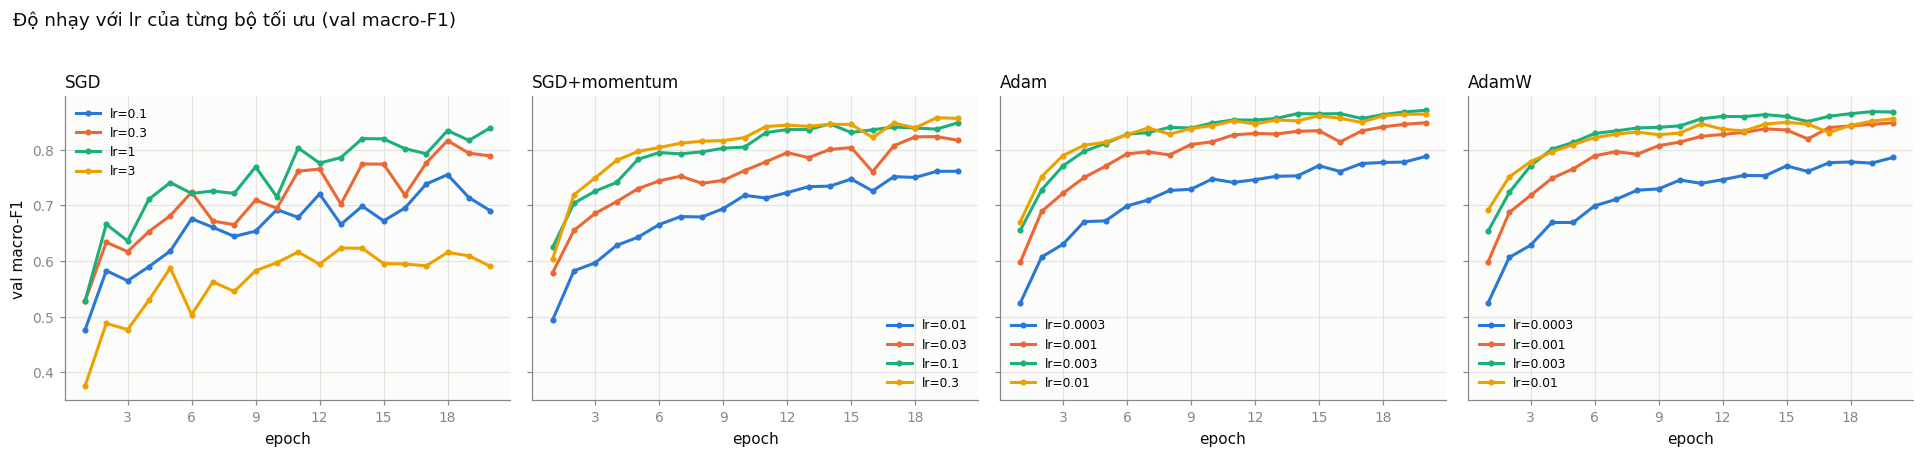

In [16]:
best_per_opt = {name: max(runs, key=f1_of) for name, runs in opt_runs.items()}
print("Mỗi bộ tối ưu ở lr tốt nhất của nó (theo val macro-F1):")
table([r["cfg"]["exp_id"] for r in best_per_opt.values()])
for name, runs in opt_runs.items():
    vals = [f1_of(r) for r in runs if f1_of(r) > -math.inf]
    print(f"  {OPT_LABEL[name]:13s} độ nhạy với lr: macro-F1 từ {min(vals):.4f} đến {max(vals):.4f} (biên độ {max(vals) - min(vals):.4f}),"
          f" lr tốt nhất = {best_per_opt[name]['cfg']['lr']:g}" + ("  <- nằm ở BIÊN lưới lr" if best_per_opt[name]['cfg']['lr'] in (runs[0]['cfg']['lr'], runs[-1]['cfg']['lr']) else ""))

# Kiểm chứng: AdamW với weight_decay=0 phải trùng Adam ở cùng lr
r_w0 = run(dict(exp_id="opt-adamw-wd0-lr0.001", group="optimizer", optimizer="adamw", lr=1e-3, weight_decay=0.0,
                description="AdamW, lr=1e-3, weight_decay=0 (kiểm chứng trùng Adam)"), note="Kiểm chứng AdamW(wd=0) ≡ Adam.")
r_a = RESULTS["opt-adam-lr0.001"]
print("\nAdamW(wd=0) vs Adam, lr=1e-3: |Δ val_loss| lớn nhất qua các epoch = %.2e"
      % max(abs(a - b) for a, b in zip(r_w0["history"]["val_loss"], r_a["history"]["val_loss"])))

plot_compare(list(best_per_opt.values()), ["val_loss", "val_macro_f1", "grad_norm"], f"{FIG_DIR}/compare_optimizer.png",
             "Bộ tối ưu, mỗi bộ ở lr tốt nhất của nó")
plot_lr_sweep({OPT_LABEL[k]: v for k, v in opt_runs.items()}, "val_macro_f1", f"{FIG_DIR}/compare_optimizer_lr.png",
              "Độ nhạy với lr của từng bộ tối ưu (val macro-F1)")
display(Image(filename=f"{FIG_DIR}/compare_optimizer.png")); display(Image(filename=f"{FIG_DIR}/compare_optimizer_lr.png"))

**Đối chiếu sau khi chạy.**

| Bộ tối ưu (lr tốt nhất) | exp_id | val macro-F1 | so với TB baseline 0,8607 | vượt 2σ = 0,0060? |
|---|---|---|---|---|
| SGD (lr = 1) | `opt-sgd-lr1` | 0,8344 | −0,0263 | Có (kém hơn) |
| SGD+momentum (lr = 0,3) | `opt-sgdm-lr0.3` ≡ `base-s1` | 0,8573 | −0,0034 | Không |
| Adam (lr = 3e-3) | `opt-adam-lr0.003` | **0,8677** | +0,0070 | Có (sát ngưỡng) |
| AdamW (lr = 3e-3, wd = 0,01) | `opt-adamw-lr0.003` | 0,8646 | +0,0039 | Không |

- **(1) Đúng một phần:** Adam đứng đầu nhưng chỉ hơn trung bình baseline 0,0070, vừa qua ngưỡng 2σ = 0,0060 với **một** seed của
  Adam → bằng chứng yếu; AdamW không vượt nhiễu. Kết luận trung thực: khi mỗi bộ được chỉnh lr, Adam ≈ AdamW ≳ SGD+momentum, và cả ba
  hơn SGD thuần rõ rệt (−0,026).
- **(2) Đúng ở bước nhỏ, sai ở bước lớn:** SGD lr = 1 (0,8344) ≈ SGD+momentum lr = 0,1 (0,8390), đúng quy tắc bước hiệu dụng
  lr/(1−μ). Nhưng SGD lr = 3 (0,6155) kém xa SGD+momentum lr = 0,3 (0,8573): momentum lấy trung bình ~10 gradient nên bước ít nhiễu hơn,
  còn SGD thuần đi trọn một bước dài theo một lô nhiễu.
- **(3) Sai về lr = 1e-2:** Adam ở 1e-2 vẫn đạt 0,8639 (không sụp). Adam ít nhạy với lr nhất: trên dải lr rộng 33 lần, biên độ macro-F1
  của Adam là 0,080 (AdamW 0,079), SGD+momentum 0,096 (dải 30 lần), SGD 0,219. Cơ chế: Adam chia bước cho √v̂ nên độ dài bước theo từng
  tham số gần như không phụ thuộc độ lớn gradient.
- **(4) Đúng ở lr ≤ 3e-3, sai ở lr = 1e-2:** AdamW(wd = 0) trùng khít Adam (|Δ val loss| = 0 ở mọi epoch). Với wd = 0,01: ở lr = 3e-3 chênh −0,0031 (trong nhiễu),
  nhưng ở lr = 1e-2 thì AdamW kém Adam 0,0147 (0,8492 so với 0,8639) vì suy giảm mỗi bước là lr·wd, lớn dần theo lr.
- **Nếu không chỉnh lr thì kết luận đảo chiều:** ở cùng lr = 0,01, Adam (0,8639) "thắng" SGD+momentum (0,7613) tới 0,10; ở lr riêng
  tốt nhất, khoảng cách chỉ còn 0,010. "Adam thắng SGD" khi dùng một lr duy nhất chủ yếu đo việc lr đó hợp với bộ nào.
- **Hạn chế:** lr tốt nhất của SGD+momentum nằm ở biên lưới; mỗi cấu hình 1 seed.

### 3.3 Hyper-parameter (`hp-*`)

Đổi lần lượt: batch (128, 2048), batch 2048 kèm lr ×4 (quy tắc tăng lr theo lô — **đổi hai yếu tố**, có ghi chú), độ rộng (`M-wide`),
độ sâu (`M-deep`), weight decay 1e-4, lịch lr cosine.

**Dự đoán trước:**
- *Batch 128:* cùng 20 epoch nhưng số bước gấp 4 (2 906 so với 727 bước/epoch) → tốt hơn baseline, đổi lại mỗi epoch chậm hơn.
  *Batch 2048:* chỉ 182 bước/epoch → kém baseline rõ. Tăng lr ×4 sẽ lấy lại phần lớn khoảng cách (nếu lr đó chưa gây dao động).
- *M-wide* (161 287 tham số) tốt hơn baseline vì baseline đang **chưa khớp** (train ≈ val loss, vẫn đang giảm); *M-deep* cũng tốt hơn
  nhưng ít hơn (chỉ thêm 7 808 tham số).
- *Weight decay 1e-4:* mô hình chưa quá khớp nên chính quy hoá không giúp; chênh lệch nằm trong nhiễu hoặc hơi âm.
- *Cosine:* lr giảm dần về 0 giúp cuối quá trình bớt nhiễu → val loss mượt và thấp hơn một chút.

[cache] hp-bs128                 step0 2.2691 | best ep 14 val_loss 0.3209 acc 0.8749 macroF1 0.7951 | train 0.3030 | 5.2s/ep


[cache] hp-bs2048                step0 2.2691 | best ep 18 val_loss 0.2437 acc 0.9014 macroF1 0.8338 | train 0.2303 | 0.3s/ep
[cache] hp-bs2048-lrx4           step0 2.2691 | best ep 11 val_loss 1.2052 acc 0.4876 macroF1 0.0936 | train 1.2079 | 0.3s/ep
[cache] hp-wide                  step0 1.9182 | best ep 20 val_loss 0.1998 acc 0.9226 macroF1 0.8747 | train 0.1697 | 1.3s/ep
[cache] hp-deep                  step0 1.9099 | best ep 20 val_loss 0.2222 acc 0.9138 macroF1 0.8413 | train 0.1977 | 1.5s/ep
[cache] hp-wd1e-4                step0 2.2691 | best ep 18 val_loss 0.2823 acc 0.8853 macroF1 0.8123 | train 0.2725 | 1.3s/ep
[cache] hp-cosine                step0 2.2691 | best ep 20 val_loss 0.1651 acc 0.9367 macroF1 0.8947 | train 0.1356 | 1.3s/ep
                   lr  step0  best_val_loss  best_ep  val_acc  val_macro_f1  dF1_vs_base vượt_2σ  gap_val-train  s/epoch diverged  n_steps
exp_id                                                                                                  

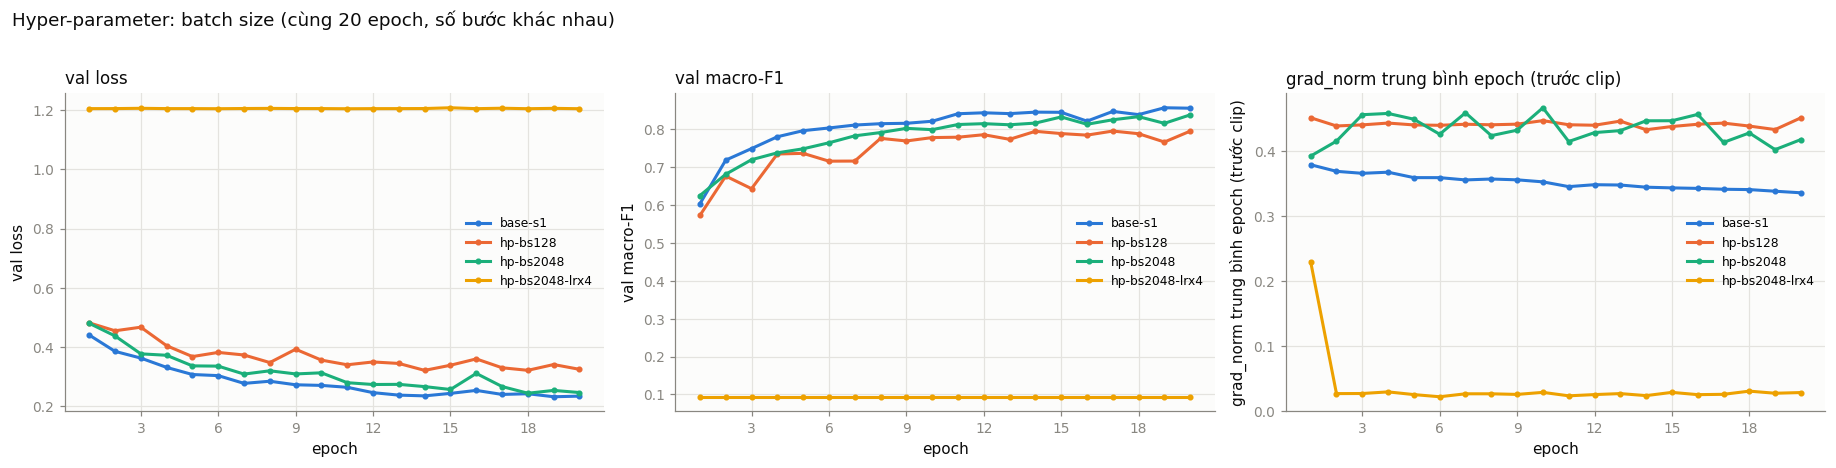

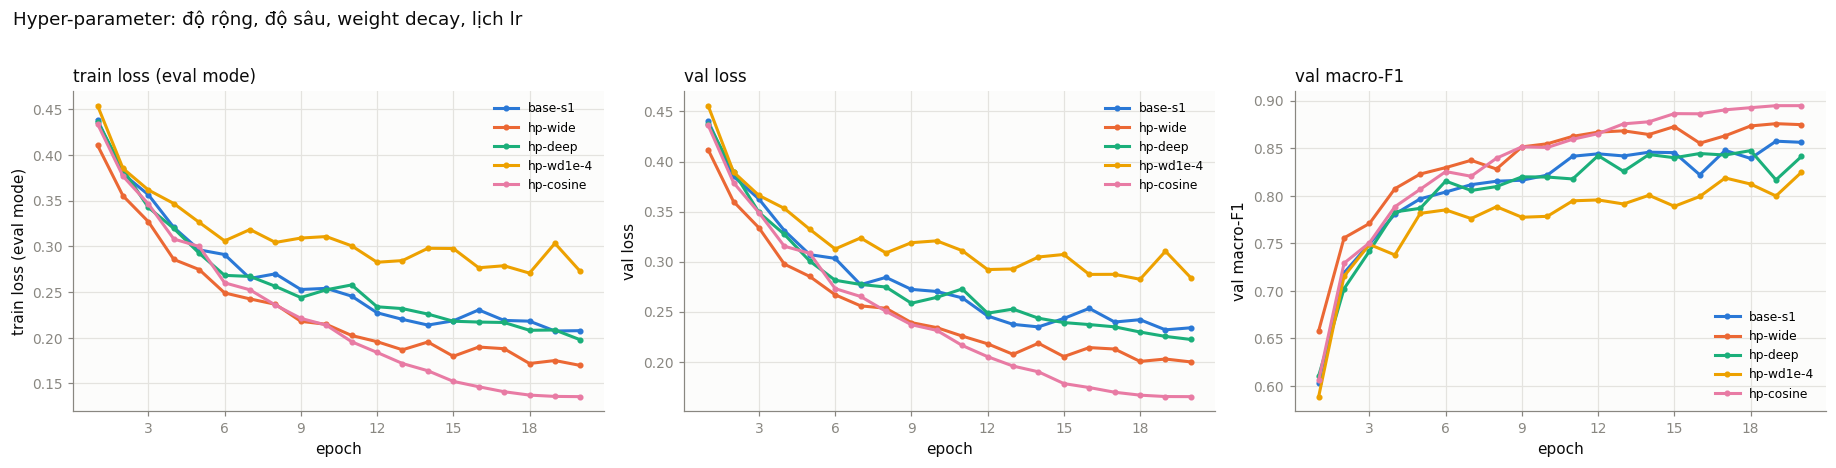

In [17]:
lr0 = BASE_CFG["lr"]
hp_cfgs = [
    dict(exp_id="hp-bs128", batch=128, description="batch 128 (số bước/epoch ×4)"),
    dict(exp_id="hp-bs2048", batch=2048, description="batch 2048 (số bước/epoch ÷4)"),
    dict(exp_id="hp-bs2048-lrx4", batch=2048, lr=lr0 * 4, description=f"batch 2048 và lr ×4 = {lr0 * 4:g} (đổi HAI yếu tố: quy tắc tăng lr theo lô)"),
    dict(exp_id="hp-wide", hidden=(512, 256), description="M-wide 54-512-256-7 (161 287 tham số)"),
    dict(exp_id="hp-deep", hidden=(256, 128, 64), description="M-deep 54-256-128-64-7 (55 687 tham số)"),
    dict(exp_id="hp-wd1e-4", weight_decay=1e-4, description="weight decay 1e-4 (L2 trong SGD)"),
    dict(exp_id="hp-cosine", scheduler="cosine", description="lịch lr cosine về 0 trong 20 epoch"),
]
hp_runs = {c["exp_id"]: run({**c, "group": "hparam"}) for c in hp_cfgs}
steps = {i: RESULTS[i]["summary"]["n_steps"] for i in ["base-s1", *hp_runs]}
df = table(["base-s1", *hp_runs], extra=("n_steps",))
plot_compare([BASE, hp_runs["hp-bs128"], hp_runs["hp-bs2048"], hp_runs["hp-bs2048-lrx4"]], ["val_loss", "val_macro_f1", "grad_norm"],
             f"{FIG_DIR}/compare_hparam_batch.png", "Hyper-parameter: batch size (cùng 20 epoch, số bước khác nhau)")
plot_compare([BASE, hp_runs["hp-wide"], hp_runs["hp-deep"], hp_runs["hp-wd1e-4"], hp_runs["hp-cosine"]], ["train_loss", "val_loss", "val_macro_f1"],
             f"{FIG_DIR}/compare_hparam_model.png", "Hyper-parameter: độ rộng, độ sâu, weight decay, lịch lr")
display(Image(filename=f"{FIG_DIR}/compare_hparam_batch.png")); display(Image(filename=f"{FIG_DIR}/compare_hparam_model.png"))

**Đối chiếu sau khi chạy** (TB baseline 0,8607; 2σ = 0,0060):

| exp_id | val macro-F1 | chênh | số bước | s/epoch | so với dự đoán |
|---|---|---|---|---|---|
| `hp-bs128` | 0,7951 | −0,0656 | 58 120 | 5,16 | **sai** (dự đoán tốt hơn) |
| `hp-bs2048` | 0,8338 | −0,0269 | 3 640 | 0,33 | đúng |
| `hp-bs2048-lrx4` | 0,0936 | −0,7671 | 3 640 | 0,34 | **sai** (sụp về đoán lớp đa số) |
| `hp-wide` | 0,8747 | +0,0140 | 14 540 | 1,31 | đúng |
| `hp-deep` | 0,8413 | −0,0195 | 14 540 | 1,47 | **sai** (dự đoán tốt hơn) |
| `hp-wd1e-4` | 0,8123 | −0,0484 | 14 540 | 1,32 | đúng hướng, mạnh hơn dự đoán |
| `hp-cosine` | **0,8947** | **+0,0340** | 14 540 | 1,31 | đúng hướng, mạnh hơn dự đoán nhiều |

- **Batch 128 kém hơn dù số bước gấp 4:** lr = 0,3 được dò cho batch 512. Nhiễu của bước SGD tỉ lệ với lr/B, nên giữ lr mà giảm B 4
  lần là tăng nhiễu 4 lần: val loss dừng ở 0,3209 (best epoch 14) so với 0,2318. Kết luận chỉ đúng "ở lr cố định"; batch 128 với lr
  nhỏ hơn chưa được thử. Giá phải trả về thời gian: 5,16 s/epoch so với 1,29.
- **Batch 2048:** ít bước hơn 4 lần nên kém 0,027, nhưng nhanh hơn 3,9 lần mỗi epoch. **Tăng lr ×4 (1,2) không cứu mà phá:** mô hình
  sụp ngay về "luôn đoán lớp 1" (accuracy 0,4876 = mốc đa số, val loss 1,205 ≈ entropy của phân phối nhãn, `grad_norm` lớn nhất 14,8).
  Quy tắc tăng lr theo lô trong slide **đi kèm khởi động (warmup)**; ở đây không có warmup, và lr gốc 0,3 vốn đã sát ngưỡng ổn định.
- **Độ rộng giúp, độ sâu thì không:** `M-wide` +0,0140 (vượt 2σ, val loss 0,1998) với thời gian mỗi epoch gần như không đổi trên GPU.
  `M-deep` có val loss 0,2222 và accuracy 0,9138 ngang baseline nhưng macro-F1 thấp hơn 0,0195: khác biệt nằm ở lớp hiếm; với 1 seed tôi
  chỉ kết luận "không thấy lợi ích", chưa kết luận "sâu hơn thì tệ hơn".
- **Weight decay 1e-4 làm kém đi 0,048:** train loss cuối 0,2725 so với 0,2078 → mô hình vốn chưa khớp lại bị kéo trọng số về 0.
- **Cosine là thay đổi một-yếu-tố có lợi nhất:** +0,0340 (gấp 5,7 lần 2σ), val loss 0,1651. Cơ chế: lr 0,3 hằng số làm val loss nhấp
  nhô đến cuối; cosine giữ lr lớn lúc đầu để đi nhanh rồi giảm dần về 0 để "lắng" xuống, đường val mượt và best epoch = 20.

### 3.4 Dropout (`drop-*`)

`q ∈ {0,1; 0,3; 0,5}` đặt sau ReLU của hai lớp ẩn. Train loss vẫn đo ở `eval()` nên so được với val loss.

**Dự đoán trước:** baseline chưa quá khớp (khoảng cách val − train loss rất nhỏ), nên dropout — thuốc cho quá khớp — sẽ **không giúp**:
càng tăng q thì năng lực hiệu dụng càng giảm, val macro-F1 giảm đơn điệu (q = 0,5 tệ nhất), khoảng cách val − train thu hẹp lại hoặc
đổi dấu. `grad_norm` tăng theo q vì gradient nhiễu hơn.

[train] drop-0.1                 step0 2.2691 | best ep 20 val_loss 0.2400 acc 0.9025 macroF1 0.8385 | train 0.2292 | 1.4s/ep
[train] drop-0.3                 step0 2.2691 | best ep 20 val_loss 0.3141 acc 0.8720 macroF1 0.7824 | train 0.3087 | 1.4s/ep
[train] drop-0.5                 step0 2.2691 | best ep 20 val_loss 0.4249 acc 0.8196 macroF1 0.5784 | train 0.4227 | 1.4s/ep
             lr  step0  best_val_loss  best_ep  val_acc  val_macro_f1  dF1_vs_base vượt_2σ  gap_val-train  s/epoch diverged
exp_id                                                                                                                     
base-s1  0.3000 2.2691         0.2318       19   0.9090        0.8573      -0.0034   Không         0.0261   1.2905        N
drop-0.1 0.3000 2.2691         0.2400       20   0.9025        0.8385      -0.0222      Có         0.0108   1.4264        N
drop-0.3 0.3000 2.2691         0.3141       20   0.8720        0.7824      -0.0783      Có         0.0054   1.4105        N
dr

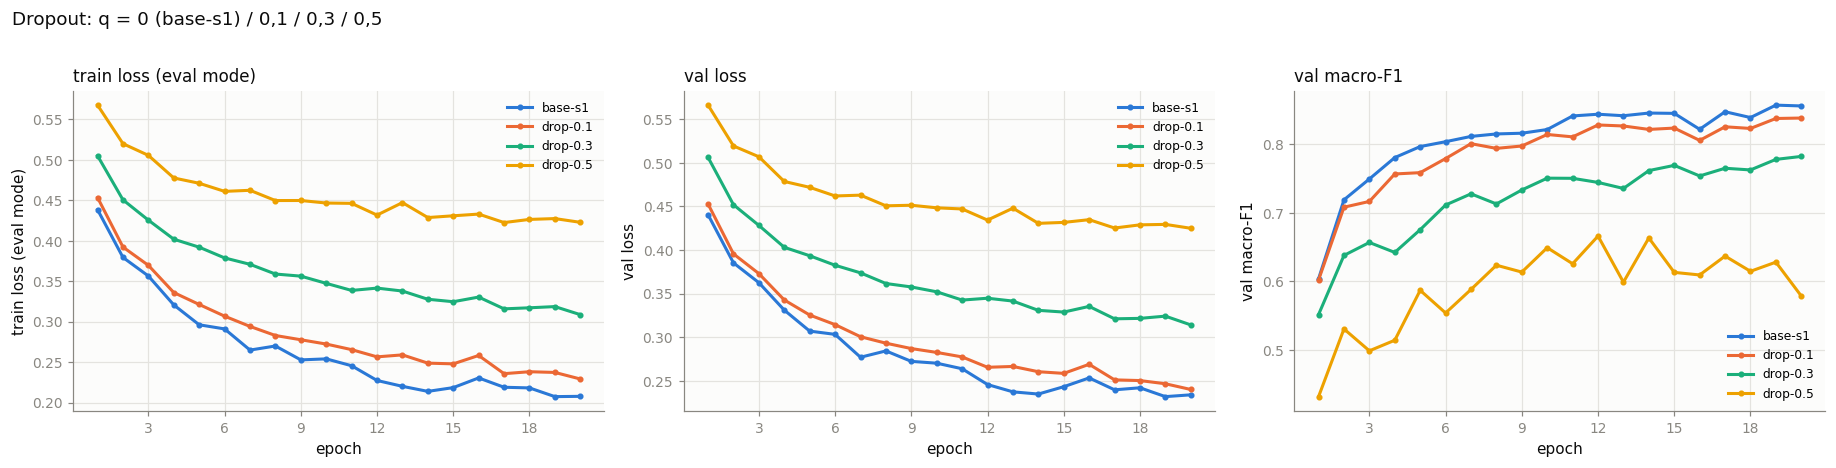

In [18]:
drop_runs = [run(dict(exp_id=f"drop-{q:g}", group="dropout", dropout=q, description=f"dropout q={q:g} sau ReLU của mỗi lớp ẩn"))
             for q in (0.1, 0.3, 0.5)]
table(["base-s1"] + [r["cfg"]["exp_id"] for r in drop_runs])
plot_compare([BASE] + drop_runs, ["train_loss", "val_loss", "val_macro_f1"], f"{FIG_DIR}/compare_dropout.png",
             "Dropout: q = 0 (base-s1) / 0,1 / 0,3 / 0,5")
display(Image(filename=f"{FIG_DIR}/compare_dropout.png"))

**Đối chiếu sau khi chạy — khớp dự đoán về macro-F1, sai về `grad_norm`.**
- Val macro-F1 giảm đơn điệu theo q: 0,8573 (q = 0, `base-s1`) → 0,8385 (`drop-0.1`, −0,0222 so với TB baseline) → 0,7824
  (`drop-0.3`, −0,0783) → 0,5784 (`drop-0.5`, −0,2823); cả ba đều vượt 2σ theo hướng **xấu đi**.
- Khoảng cách val − train loss thu hẹp đúng như kỳ vọng: 0,0261 → 0,0108 → 0,0054 → 0,0022, nhưng là vì **train loss tăng**
  (0,2078 → 0,2292 → 0,3087 → 0,4227) chứ không phải val loss giảm. Dropout chữa quá khớp, còn mô hình này đang chưa khớp, nên nó chỉ
  lấy bớt năng lực. q = 0,5 làm macro-F1 sụp mạnh hơn accuracy (0,8196) → các lớp hiếm bị bỏ rơi trước.
- **Sai:** tôi dự đoán `grad_norm` tăng theo q; thực tế trung vị giảm từ 0,347 xuống 0,28–0,29. Tôi chưa kiểm chứng cơ chế (phỏng
  đoán: một phần nơ-ron bị tắt nên tín hiệu lan ngược nhỏ hơn).
- Cả ba lần chạy có best epoch = 20 (vẫn đang học), nên huấn luyện lâu hơn có thể thu hẹp khoảng cách; chưa thử. 1 seed mỗi giá trị q.

### 3.5 Cắt gradient (`clip-*`)

`g ← g · min(1, c/‖g‖)` với ‖g‖ là chuẩn L2 toàn cục. Ngưỡng `c` được chọn **từ `grad_norm` của baseline**: lấy trung vị theo bước của
`base-s1`, để clipping kích hoạt ở khoảng một nửa số bước (nếu c lớn hơn mọi `grad_norm` thì clipping không làm gì cả).

Thí nghiệm phản chứng: tăng lr của baseline ×10, ×30, ×100 cho tới khi huấn luyện **không clip** bị hỏng (NaN hoặc macro-F1 tụt hơn 0,05
so với baseline), rồi chạy lại **đúng lr đó có clip**.

**Dự đoán trước:** (1) Ở lr bình thường, clip với c = trung vị làm khoảng một nửa số bước ngắn lại → tương đương giảm lr hiệu dụng → kết
quả ngang hoặc hơi kém baseline, không có lợi vì baseline không có gai gradient gây hại. (2) Ở lr cao, không clip sẽ dao động mạnh hoặc
NaN, `grad_norm` có gai rất lớn; có clip thì mỗi bước bị chặn độ dài ≤ lr·c nên huấn luyện được cứu (không NaN, macro-F1 cao hơn hẳn),
dù vẫn chưa chắc bằng baseline ở lr tốt. (3) Ở lr cao gấp k lần, ngưỡng `c/k` (giữ nguyên độ dài bước tối đa lr·c như ở lr bình thường) sẽ
cứu tốt hơn ngưỡng `c` gốc, vì với `c` gốc mỗi bước vẫn có thể dài gấp k lần bước của baseline.

base-s1: trung vị grad_norm = 0.347, p90 = 0.406, max = 2.844  ->  chọn c = 0.35
[cache] clip-c0.35               step0 2.2691 | best ep 19 val_loss 0.2287 acc 0.9089 macroF1 0.8581 | train 0.2088 | 1.3s/ep
[cache] clip-highlr3-none        step0 2.2691 | best ep 17 val_loss 1.2090 acc 0.4876 macroF1 0.0936 | train 1.2124 | 1.3s/ep

=> lr cao dùng cho phép thử phản chứng: 3 (không clip: diverged=False, macro-F1=0.09364999018625454)
[cache] clip-highlr3-c0.35       step0 2.2691 | best ep 17 val_loss 0.9661 acc 0.5249 macroF1 0.1928 | train 0.9866 | 1.3s/ep
[cache] clip-highlr3-c0.035      step0 2.2691 | best ep 18 val_loss 0.2295 acc 0.9094 macroF1 0.8549 | train 0.2110 | 1.3s/ep
                        lr  step0  best_val_loss  best_ep  val_acc  val_macro_f1  dF1_vs_base vượt_2σ  gap_val-train  s/epoch diverged  clip_frac  grad_norm_p50  grad_norm_max
exp_id                                                                                                                                   

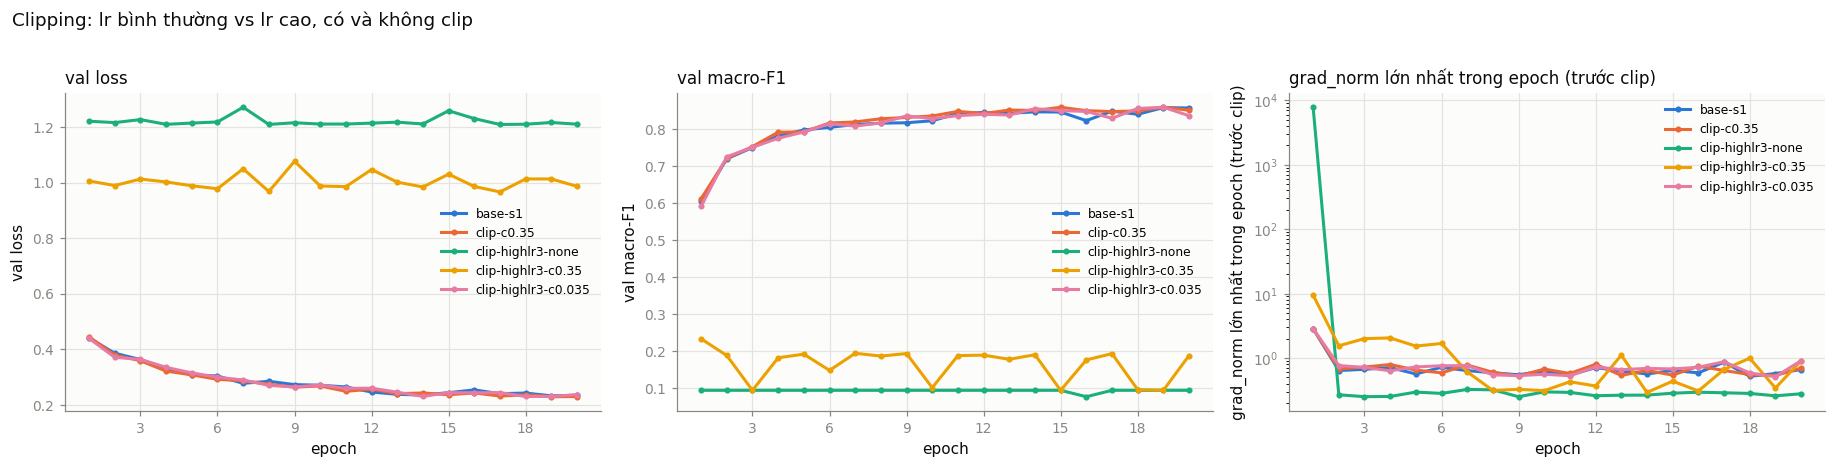

In [19]:
s = BASE["summary"]
C = float(f"{s['grad_norm_p50']:.2g}")          # trung vị grad_norm theo bước của base-s1, làm tròn 2 chữ số có nghĩa
print(f"base-s1: trung vị grad_norm = {s['grad_norm_p50']:.3f}, p90 = {s['grad_norm_p90']:.3f}, max = {s['grad_norm_max']:.3f}  ->  chọn c = {C:g}")

clip_runs = [run(dict(exp_id=f"clip-c{C:g}", group="clipping", clip_norm=C, description=f"clip c={C:g} (trung vị grad_norm của baseline), lr bình thường"),
                 note="c chọn = trung vị grad_norm theo bước của base-s1.")]

unstable = None
for mult in (10, 30, 100):
    lr_hi = lr0 * mult
    r = run(dict(exp_id=f"clip-highlr{lr_hi:g}-none", group="clipping", lr=lr_hi,
                 description=f"lr ×{mult} = {lr_hi:g}, KHÔNG clip (tìm lr gây mất ổn định)"), note="Đối chứng lr cao không clip.")
    clip_runs.append(r)
    unstable = r
    if r["summary"]["diverged"] or f1_of(r) < BASE_F1_MEAN - 0.05:
        break
lr_hi = unstable["cfg"]["lr"]
print(f"\n=> lr cao dùng cho phép thử phản chứng: {lr_hi:g} (không clip: diverged={unstable['summary']['diverged']}, macro-F1={unstable['summary']['val_macro_f1']})")
r_hc = run(dict(exp_id=f"clip-highlr{lr_hi:g}-c{C:g}", group="clipping", lr=lr_hi, clip_norm=C,
                description=f"lr = {lr_hi:g} CÓ clip c={C:g}"), note="Phép thử phản chứng: cùng lr cao, có clip. Đổi HAI yếu tố so với baseline (lr và clip); so với clip-highlr-none ở cùng lr.")
clip_runs.append(r_hc)
mult_hi = lr_hi / lr0
C_small = float(f"{C / mult_hi:.2g}")           # giữ nguyên độ dài bước tối đa lr·c của lr bình thường
r_hc2 = run(dict(exp_id=f"clip-highlr{lr_hi:g}-c{C_small:g}", group="clipping", lr=lr_hi, clip_norm=C_small,
                 description=f"lr = {lr_hi:g} CÓ clip c={C_small:g} (= c/{mult_hi:g}: cùng độ dài bước tối đa với lr bình thường)"),
            note="Đổi HAI yếu tố so với baseline (lr và clip); so với clip-highlr-none ở cùng lr.")
clip_runs.append(r_hc2)
table(["base-s1"] + [r["cfg"]["exp_id"] for r in clip_runs], extra=("clip_frac", "grad_norm_p50", "grad_norm_max"))
plot_compare([BASE, clip_runs[0], unstable, r_hc, r_hc2], ["val_loss", "val_macro_f1", "grad_norm_max"], f"{FIG_DIR}/compare_clipping.png",
             "Clipping: lr bình thường vs lr cao, có và không clip")
display(Image(filename=f"{FIG_DIR}/compare_clipping.png"))

**Đối chiếu sau khi chạy.** Ngưỡng `c = 0,35` (trung vị `grad_norm` theo bước của `base-s1` là 0,347).

| exp_id | lr | c | val macro-F1 | tỉ lệ bước bị clip | `grad_norm` lớn nhất |
|---|---|---|---|---|---|
| `base-s1` | 0,3 | — | 0,8573 | 0 | 2,84 |
| `clip-c0.35` | 0,3 | 0,35 | 0,8581 | 66,6% | 2,84 |
| `clip-highlr3-none` | 3 | — | 0,0936 | 0 | **7 810** |
| `clip-highlr3-c0.35` | 3 | 0,35 | 0,1928 | 3,3% | 9,43 |
| `clip-highlr3-c0.035` | 3 | 0,035 | **0,8549** | 100% | 2,84 |

- **(1) Đúng:** ở lr bình thường, clipping kích hoạt ở 2/3 số bước nhưng kết quả 0,8581 chỉ lệch −0,0026 so với TB baseline, nằm trong
  nhiễu. Baseline không có gai gradient gây hại nên clipping không có gì để chữa.
- **lr ×10 = 3, không clip:** không ra NaN nhưng **sụp về đoán lớp đa số** (accuracy 0,4876, macro-F1 0,0936) và không hồi phục; có
  gai `grad_norm` tới 7 810. Sau cú nhảy đó trung vị `grad_norm` chỉ còn 0,069: mạng gần như chết (ReLU tắt), giống `init-zeros`.
- **(2) Sai:** cùng lr = 3 với `c = 0,35` **không cứu được** (0,1928). Độ dài bước tối đa là lr·c = 1,05, vẫn gấp 10 lần baseline
  (0,3·0,35), đủ để phá mạng ngay những bước đầu; sau đó gradient nhỏ nên chỉ 3,3% số bước còn bị clip.
- **(3) Đúng:** với `c = 0,035` (giữ lr·c = 0,105 như ở lr bình thường), mọi bước đều bị clip và huấn luyện được **cứu hoàn toàn**:
  0,8549, chỉ lệch −0,0058 so với TB baseline (trong nhiễu). Khi 100% số bước bị clip, thuật toán trở thành "gradient chuẩn hoá" với
  độ dài bước cố định lr·c.
- **Kết luận:** clipping giải quyết bước nhảy quá dài do gradient/lr lớn, và đại lượng cần chọn là **lr·c** chứ không phải riêng `c`.
  Ngưỡng `c` chọn từ `grad_norm` ở lr bình thường không tự động đúng cho lr khác. Mỗi cấu hình 1 seed.

### 3.6 Mixed precision (`amp-*`)

FP16: `torch.autocast(dtype=float16)` + `GradScaler` (luôn `unscale_` trước khi đo `grad_norm`). BF16: `autocast(dtype=bfloat16)`, không
cần GradScaler. Tham số vẫn là FP32; autocast chỉ hạ độ chính xác của phép toán trong forward. Thời gian đo chỉ gồm vòng huấn luyện.

**Dự đoán trước:** độ chính xác FP16/BF16 sẽ **ngang FP32** (chênh trong nhiễu) vì mạng nhỏ, logit và gradient nằm gọn trong khoảng biểu
diễn. Về tốc độ: mạng chỉ 47 879 tham số nên thời gian bị chi phối bởi chi phí gọi kernel và lập chỉ mục lô, không phải phép nhân ma
trận → mixed precision **không nhanh hơn**; trên phần cứng không có lệnh FP16/BF16 gốc (CPU không có AVX512-FP16/AMX, hoặc GPU T4 với
BF16) nó còn chậm hơn do phải giả lập/chuyển kiểu. Bộ nhớ cực đại (nếu đo được trên GPU) giảm rất ít vì dữ liệu và tham số vẫn là FP32.

[cache] amp-fp16                 step0 2.2691 | best ep 15 val_loss 0.2220 acc 0.9112 macroF1 0.8597 | train 0.2033 | 1.8s/ep
[cache] amp-bf16                 step0 2.2691 | best ep 20 val_loss 0.2250 acc 0.9102 macroF1 0.8520 | train 0.2026 | 1.5s/ep
             lr  step0  best_val_loss  best_ep  val_acc  val_macro_f1  dF1_vs_base vượt_2σ  gap_val-train  s/epoch diverged  peak_mem_MB  total_time_s
exp_id                                                                                                                                                
base-s1  0.3000 2.2691         0.2318       19   0.9090        0.8573      -0.0034   Không         0.0261   1.2905        N     173.0317       26.2019
amp-fp16 0.3000 2.2691         0.2220       15   0.9112        0.8597      -0.0010   Không         0.0204   1.7789        N     179.1699       35.9422
amp-bf16 0.3000 2.2691         0.2250       20   0.9102        0.8520      -0.0087      Có         0.0223   1.5456        N     179.3521       3

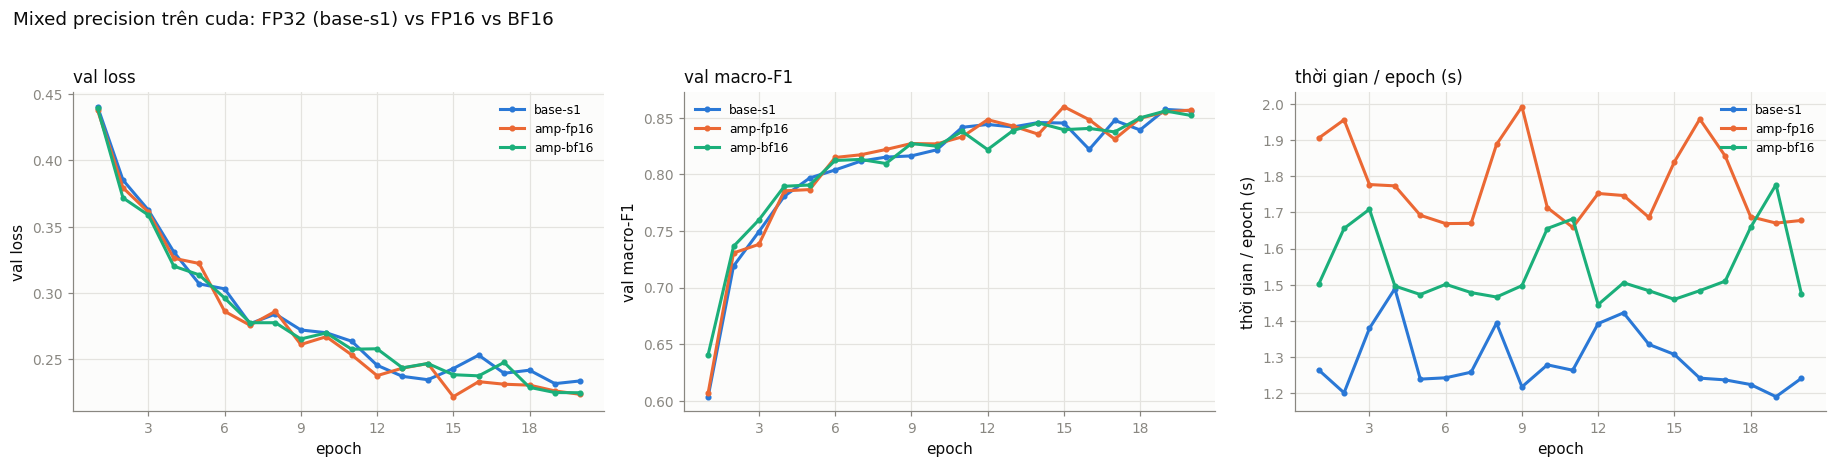

In [20]:
amp_runs, AMP_FAIL = [], {}
for prec in ("fp16", "bf16"):
    try:
        amp_runs.append(run(dict(exp_id=f"amp-{prec}", group="amp", precision=prec,
                                 description=f"mixed precision {prec.upper()}" + (" + GradScaler" if prec == "fp16" else " (không GradScaler)")),
                            note=f"autocast trên {device}."))
    except Exception as e:                       # phần cứng/phiên bản không hỗ trợ: ghi lý do, không dừng notebook
        AMP_FAIL[prec] = f"{type(e).__name__}: {e}"
        print(f"amp-{prec} KHÔNG chạy được trên {device}: {AMP_FAIL[prec]}")
if amp_runs:
    table(["base-s1"] + [r["cfg"]["exp_id"] for r in amp_runs], extra=("peak_mem_MB", "total_time_s"))
    plot_compare([BASE] + amp_runs, ["val_loss", "val_macro_f1", "epoch_time_s"], f"{FIG_DIR}/compare_amp.png",
                 f"Mixed precision trên {device}: FP32 (base-s1) vs FP16 vs BF16")
    display(Image(filename=f"{FIG_DIR}/compare_amp.png"))

**Đối chiếu sau khi chạy (Tesla T4) — khớp dự đoán về tốc độ.**

| exp_id | val macro-F1 | chênh so với TB baseline | s/epoch | peak_mem_MB |
|---|---|---|---|---|
| `base-s1` (FP32) | 0,8573 | −0,0034 | 1,29 | 173,0 |
| `amp-fp16` | 0,8597 | −0,0010 (trong nhiễu) | 1,78 | 179,2 |
| `amp-bf16` | 0,8520 | −0,0087 (vượt 2σ, sát ngưỡng) | 1,55 | 179,4 |

- **Không nhanh hơn mà chậm hơn:** FP16 chậm hơn FP32 38%, BF16 chậm hơn 20%. Mạng chỉ có 47 879 tham số, mỗi bước là vài phép nhân
  ma trận rất nhỏ nên thời gian do chi phí gọi kernel, lập chỉ mục lô và đồng bộ quyết định; autocast thêm các phép chuyển kiểu, FP16
  thêm `GradScaler` (scale, unscale, kiểm tra inf). Mixed precision chỉ có lợi khi phép toán ma trận đủ lớn để chiếm phần lớn thời gian.
- **Độ chính xác:** FP16 ngang FP32. BF16 thấp hơn 0,0087, vừa qua ngưỡng 2σ = 0,0060 với một seed → chưa đủ để kết luận BF16 kém hơn
  (BF16 chỉ có 8 bit phần định trị so với 11 bit của FP16 nên điều này có thể có thật, nhưng tôi chưa kiểm chứng bằng nhiều seed).
- **Dấu vết của GradScaler:** `amp-fp16` chỉ có 14 536 bước có gradient hữu hạn trên 14 540 bước → ở 4 bước gradient sau khi unscale
  là inf (hệ số scale khởi đầu 65 536 làm tràn FP16); `scaler.step` bỏ qua các bước đó và `scaler.update` hạ hệ số xuống. Đây chính là
  lý do FP16 cần `s`: khoảng biểu diễn hẹp (lớn nhất ≈ 65 504, nhỏ nhất ≈ 6e-5 ở dạng chuẩn) nên gradient nhỏ dễ thành 0 và giá trị lớn
  dễ tràn; BF16 giữ nguyên dải số mũ của FP32 nên không cần.
- **Bộ nhớ:** không giảm (179 MB so với 173 MB). **Lưu ý về cột này:** `peak_mem_MB` tăng ≈ 0,18 MB sau **mỗi** lần chạy trong
  notebook, đúng bằng một bản sao tham số FP32 (47 879 × 4 byte) — trạng thái tốt nhất của các lần chạy trước vẫn nằm trên GPU. Mức
  chênh 6 MB giữa `base-s1` và `amp-fp16` là do 30 lần chạy xen giữa (trong đó có một `M-wide`) chứ không do AMP: `amp-fp16` chỉ hơn lần chạy ngay trước nó
  (`clip-highlr3-c0.035`, 178,99 MB) đúng 0,18 MB. Tức là sau khi trừ phần trôi, AMP **không đổi** bộ nhớ cực đại: dữ liệu nằm sẵn
  trên GPU và tham số đều là FP32, phần kích hoạt FP16 của một lô 512 mẫu là không đáng kể.

### 3.7 Khởi tạo tham số (`init-*`)

`zeros` (W = 0), `normal` (N(0, 0,01²)), `xavier` (`xavier_normal_`, Var = 2/(n_vào + n_ra) — **không** phải 1/n_vào của slide),
`default` (mặc định của `nn.Linear`: U(±1/√n_vào), Var = 1/(3·n_vào)), so với `he` của baseline (Var = 2/n_vào). Bias = 0 (trừ `default`).

**Dự đoán trước:**
- `zeros`: mọi kích hoạt ẩn = ReLU(0) = 0 và W₃ = 0 nên gradient về W₁, W₂, W₃ đều bằng 0 — chỉ bias lớp ra nhận gradient. Mạng chỉ học
  được tần suất lớp: loss bước 0 = ln 7 đúng tuyệt đối, sau đó dừng ở entropy của phân phối nhãn (≈ 1,2), accuracy = 0,4876 (đoán lớp
  đa số), macro-F1 ≈ 0,094. Các nơ-ron cùng lớp nhận gradient giống hệt nhau (đối xứng không bị phá).
- `normal` 0,01: kích hoạt co lại qua từng lớp (std nhỏ dần), loss bước 0 ≈ ln 7, gradient ban đầu rất nhỏ → khởi động chậm (cao nguyên
  ở vài epoch đầu) nhưng mạng chỉ có 3 lớp nên vẫn thoát ra và học được, kém baseline một chút.
- `xavier` và `default`: kích hoạt nhỏ hơn He nhưng không co về 0 trong 3 lớp → kết quả gần baseline, chênh lệch trong nhiễu. Loss bước
  0 của chúng gần ln 7 hơn He (logit nhỏ hơn).
- Mạng 3 lớp không đủ sâu để thấy khác biệt He/Xavier như biểu đồ "30 lớp ReLU" của slide; phần dưới thử thêm một mạng 30 lớp (chỉ đo
  kích hoạt ở bước 0, không huấn luyện) để thấy hiện tượng đó.

In [21]:
# Độ lệch chuẩn kích hoạt theo lớp và loss bước 0 (seed 1, một lô 4 096 mẫu val)
rows = []
for init in ("zeros", "normal", "xavier", "default", "he"):
    set_seed(1); m = MLP(init=init).to(device)
    a = activation_stats(m, data["X_val"][:4096])
    rows.append(dict(init=init, std_sau_ReLU1=a[0], std_sau_ReLU2=a[1], std_logit=a[2],
                     step0_loss=evaluate(m, data["X_val"], data["y_val"])["loss"]))
act_df = pd.DataFrame(rows).set_index("init")
print(act_df.to_string(float_format=lambda v: f"{v:.5f}"), f"\n(ln 7 = {math.log(7):.5f})")

# Mạng 30 lớp ẩn rộng 256 (chỉ forward ở bước 0, KHÔNG huấn luyện, không thuộc bảng thí nghiệm): std sau ReLU của lớp 1, 10, 20, 30
import torch.nn as nn
deep_rows = []
for init in ("normal", "xavier", "default", "he"):
    set_seed(1)
    layers, prev = [], 54
    for _ in range(30):
        layers += [nn.Linear(prev, 256), nn.ReLU()]; prev = 256
    net = nn.Sequential(*layers).to(device); init_weights(net, init)
    stds, hcur = [], data["X_val"][:4096]
    with torch.no_grad():
        for layer in net:
            hcur = layer(hcur)
            if isinstance(layer, nn.ReLU): stds.append(hcur.std().item())
    deep_rows.append(dict(init=init, **{f"lớp {k}": stds[k - 1] for k in (1, 10, 20, 30)}))
print("\nMạng 30 lớp ReLU, std kích hoạt ở bước 0:")
print(pd.DataFrame(deep_rows).set_index("init").to_string(float_format=lambda v: f"{v:.3e}"))

         std_sau_ReLU1  std_sau_ReLU2  std_logit  step0_loss
init                                                        
zeros          0.00000        0.00000    0.00000     1.94591
normal         0.02027        0.00215    0.00027     1.94600
xavier         0.16282        0.12477    0.19156     2.02218
default        0.16028        0.06776    0.05851     1.98304
he             0.39012        0.36613    0.57728     2.26906 
(ln 7 = 1.94591)

Mạng 30 lớp ReLU, std kích hoạt ở bước 0:
            lớp 1    lớp 10    lớp 20    lớp 30
init                                           
normal  2.066e-02 6.909e-11 2.149e-20 0.000e+00
xavier  1.659e-01 8.075e-03 2.285e-04 8.455e-06
default 1.603e-01 2.259e-02 2.238e-02 2.086e-02
he      3.976e-01 4.378e-01 3.963e-01 4.694e-01


[cache] init-zeros               step0 1.9459 | best ep 16 val_loss 1.2053 acc 0.4876 macroF1 0.0936 | train 1.2087 | 1.3s/ep
[cache] init-normal              step0 1.9460 | best ep 20 val_loss 0.2204 acc 0.9137 macroF1 0.8609 | train 0.1982 | 1.3s/ep
[cache] init-xavier              step0 2.0222 | best ep 18 val_loss 0.2236 acc 0.9096 macroF1 0.8502 | train 0.2064 | 1.3s/ep
[cache] init-default             step0 1.9830 | best ep 20 val_loss 0.2170 acc 0.9145 macroF1 0.8637 | train 0.1947 | 1.3s/ep
                 lr  step0  best_val_loss  best_ep  val_acc  val_macro_f1  dF1_vs_base vượt_2σ  gap_val-train  s/epoch diverged  grad_norm_p50
exp_id                                                                                                                                        
base-s1      0.3000 2.2691         0.2318       19   0.9090        0.8573      -0.0034   Không         0.0261   1.2905        N         0.3466
init-zeros   0.3000 1.9459         1.2053       16   0.4876        

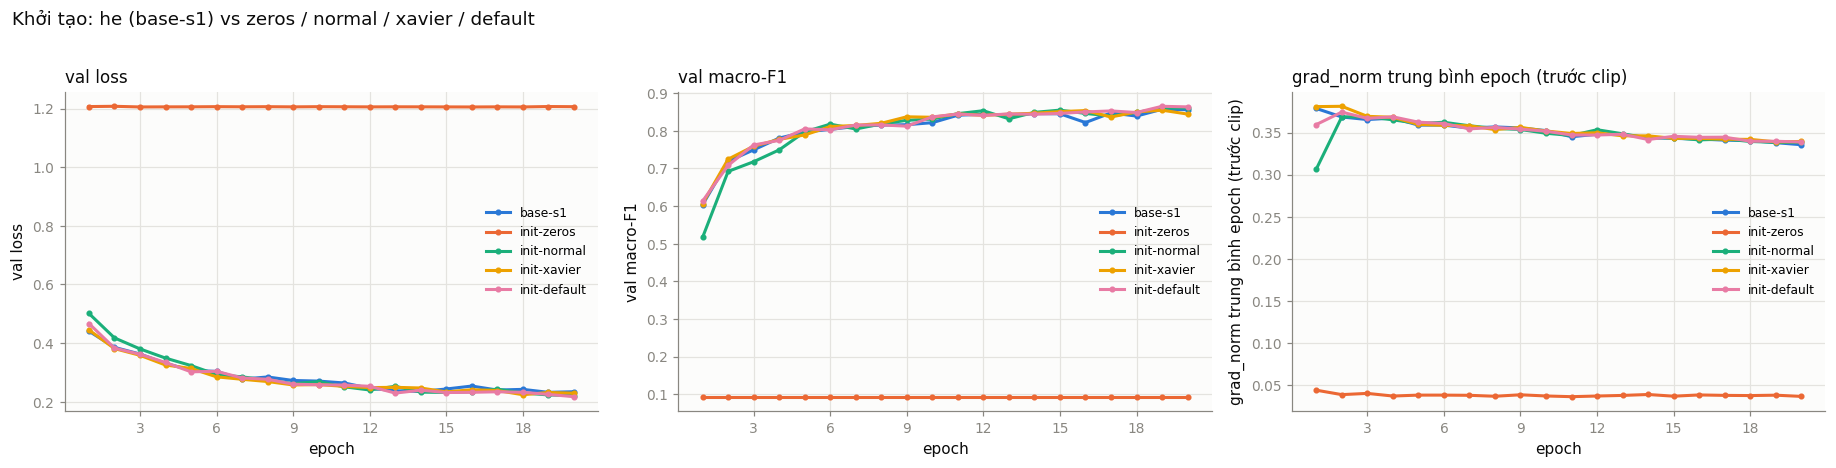

In [22]:
init_runs = [run(dict(exp_id=f"init-{name}", group="init", init=name, description=f"khởi tạo {name} thay cho he"))
             for name in ("zeros", "normal", "xavier", "default")]
table(["base-s1"] + [r["cfg"]["exp_id"] for r in init_runs], extra=("grad_norm_p50",))
plot_compare([BASE] + init_runs, ["val_loss", "val_macro_f1", "grad_norm"], f"{FIG_DIR}/compare_init.png",
             "Khởi tạo: he (base-s1) vs zeros / normal / xavier / default")
display(Image(filename=f"{FIG_DIR}/compare_init.png"))

**Đối chiếu sau khi chạy** (TB baseline 0,8607; 2σ = 0,0060):

| init | std sau ReLU 1 / ReLU 2 / logit (bước 0) | loss bước 0 | val macro-F1 | chênh |
|---|---|---|---|---|
| `zeros` | 0 / 0 / 0 | 1,94591 (= ln 7) | 0,0936 | −0,7671 |
| `normal` (0,01) | 0,0203 / 0,0022 / 0,0003 | 1,9460 | 0,8609 | +0,0002 (trong nhiễu) |
| `xavier` | 0,163 / 0,125 / 0,192 | 2,0222 | 0,8502 | −0,0105 (vượt 2σ) |
| `default` | 0,160 / 0,068 / 0,059 | 1,9830 | 0,8637 | +0,0029 (trong nhiễu) |
| `he` (`base-s1`) | 0,390 / 0,366 / 0,577 | 2,2691 | 0,8573 | −0,0034 |

- **`zeros` — đúng như dự đoán:** loss bước 0 đúng bằng ln 7; sau 20 epoch val loss 1,206 (≈ entropy của phân phối nhãn), accuracy
  0,4876, macro-F1 0,0936 — trùng khít "luôn đoán lớp đa số". Kích hoạt ẩn = ReLU(0) = 0 nên ∂L/∂W₃ = 0; W₃ = 0 nên không có gradient
  lan về lớp trước; chỉ `b₃` được học (trung vị `grad_norm` chỉ 0,033). Mọi nơ-ron cùng lớp giống hệt nhau nên đối xứng không bao giờ bị
  phá.
- **`normal` 0,01 — đúng một phần:** kích hoạt co ~10 lần qua mỗi lớp, epoch đầu chậm hơn (macro-F1 0,517 so với 0,604 của He) nhưng
  không có cao nguyên dài và kết quả cuối ngang baseline. Mạng chỉ 3 lớp nên tín hiệu chưa kịp triệt tiêu.
- **`xavier` / `default`:** `default` trong nhiễu; `xavier` thấp hơn 0,0105 (vượt 2σ nhưng nhỏ, 1 seed — chưa coi là kết luận chắc).
- **He có loss bước 0 xa ln 7 nhất** (2,27) vì logit lớn nhất, nhưng điều đó không làm kết quả cuối kém đi.
- **Mạng 3 lớp không đủ sâu để phân biệt He và Xavier; mạng 30 lớp thì có:** ở lớp 30, std kích hoạt của `he` vẫn ≈ 0,47, `xavier` còn
  8,5e-6, `normal` về 0 (tràn dưới). Với ReLU, Var = 2/n_vào bù đúng một nửa phương sai bị ReLU cắt; Xavier (2/(n_vào+n_ra) = 1/n khi
  hai chiều bằng nhau) thì mỗi lớp mất một nửa phương sai. `default` giữ ở 0,021 nhờ bias khác 0 (U(±1/√n_vào)) chứ không phải nhờ W.

### 3.8 Cấu hình cuối cùng (`final-s*`) — chọn **chỉ bằng val**

Quy tắc chọn được viết ra **trước khi chạy** và áp dụng tự động trên kết quả val ở trên (không nhìn eval):

1. **Bộ tối ưu + lr (+ weight decay của nó):** lần chạy có val macro-F1 cao nhất trong nhóm `optimizer`.
2. **Kiến trúc:** dùng `M-wide` hoặc `M-deep` (cái tốt hơn) nếu nó vượt trung bình baseline hơn 2σ; nếu không, giữ `M-base`.
3. **Dropout / lịch cosine:** chỉ thêm nếu thí nghiệm tương ứng vượt trung bình baseline hơn 2σ.
4. **Số epoch:** nếu best epoch của `base-s1` là epoch cuối (chưa hội tụ) thì tăng gấp đôi lên 40; nếu không, giữ 20.
5. Batch 512, CE, He, FP32, không clip: giữ như baseline (clip và AMP không nhằm tăng độ chính xác; batch nhỏ hơn chỉ là "thêm số bước",
   đã được thay bằng tăng epoch).

Cấu hình này **đổi nhiều yếu tố cùng lúc** so với baseline (ghi trong `notes`), nên nó không phải thí nghiệm một-yếu-tố; mỗi thành phần
được biện minh bằng thí nghiệm một-yếu-tố tương ứng, còn hiệu quả của tổ hợp được kiểm tra lại trên val với 3 seed. Seed nộp là **seed 1**
(quyết định trước, không chọn seed theo điểm eval).

**Dự đoán trước:** tổ hợp sẽ vượt baseline rõ trên val (hơn 2σ nhiều lần), chủ yếu nhờ mạng rộng hơn và huấn luyện lâu hơn — vì baseline
đang chưa khớp. Lợi ích của từng thành phần sẽ không cộng dồn hoàn toàn.

Cấu hình cuối cùng, chọn bằng val:
  - optimizer=adam, lr=0.003, wd=0 (từ opt-adam-lr0.003, val macro-F1 0.8677)
  - hidden=(512, 256) (từ hp-wide, +0.0140 > 2σ)
  - không dropout (tốt nhất là drop-0.1: -0.0222, không vượt 2σ)
  - lịch cosine (+0.0340 > 2σ)
  - epochs=20 (base-s1 đạt best ở epoch 19)
[cache] final-s1                 step0 1.9182 | best ep 20 val_loss 0.1479 acc 0.9428 macroF1 0.9139 | train 0.1124 | 1.5s/ep
[cache] final-s2                 step0 2.6520 | best ep 20 val_loss 0.1493 acc 0.9426 macroF1 0.9122 | train 0.1159 | 1.5s/ep
[cache] final-s3                 step0 2.7882 | best ep 20 val_loss 0.1476 acc 0.9426 macroF1 0.9132 | train 0.1128 | 1.5s/ep

final  val macro-F1: [0.9139 0.9122 0.9132]  TB = 0.9131  σ = 0.0008
base   val macro-F1: TB = 0.8607  2σ = 0.0060   -> chênh TB = +0.0524
             lr  step0  best_val_loss  best_ep  val_acc  val_macro_f1  dF1_vs_base vượt_2σ  gap_val-train  s/epoch diverged
exp_id                                                  

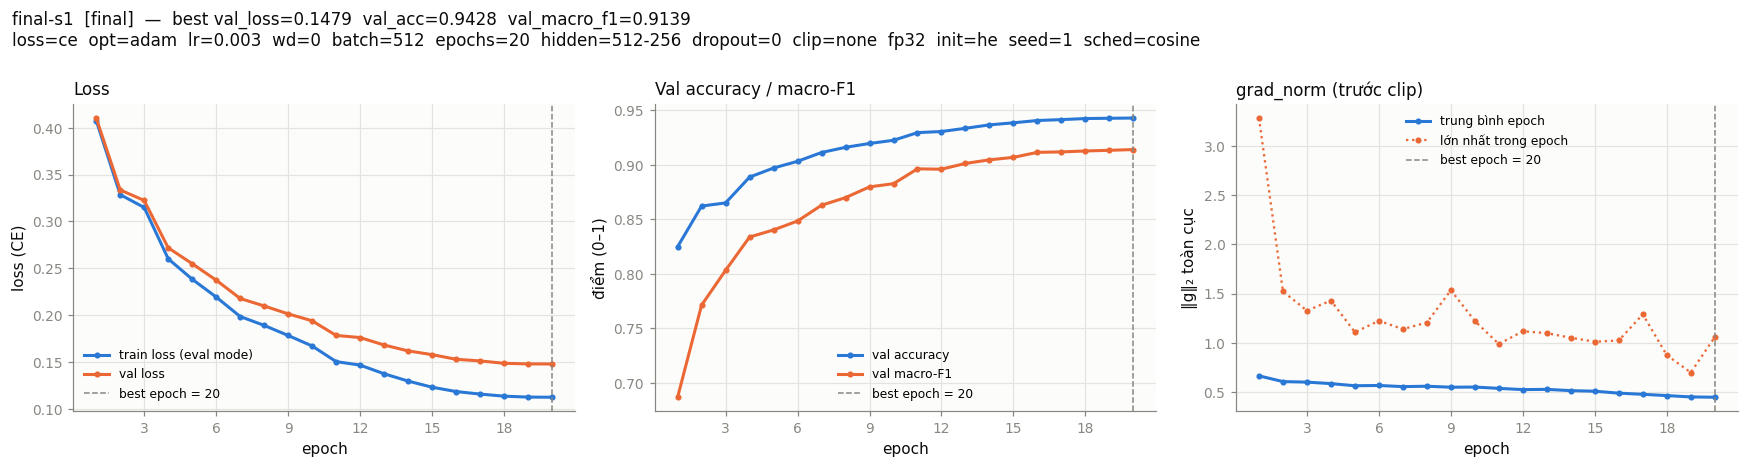

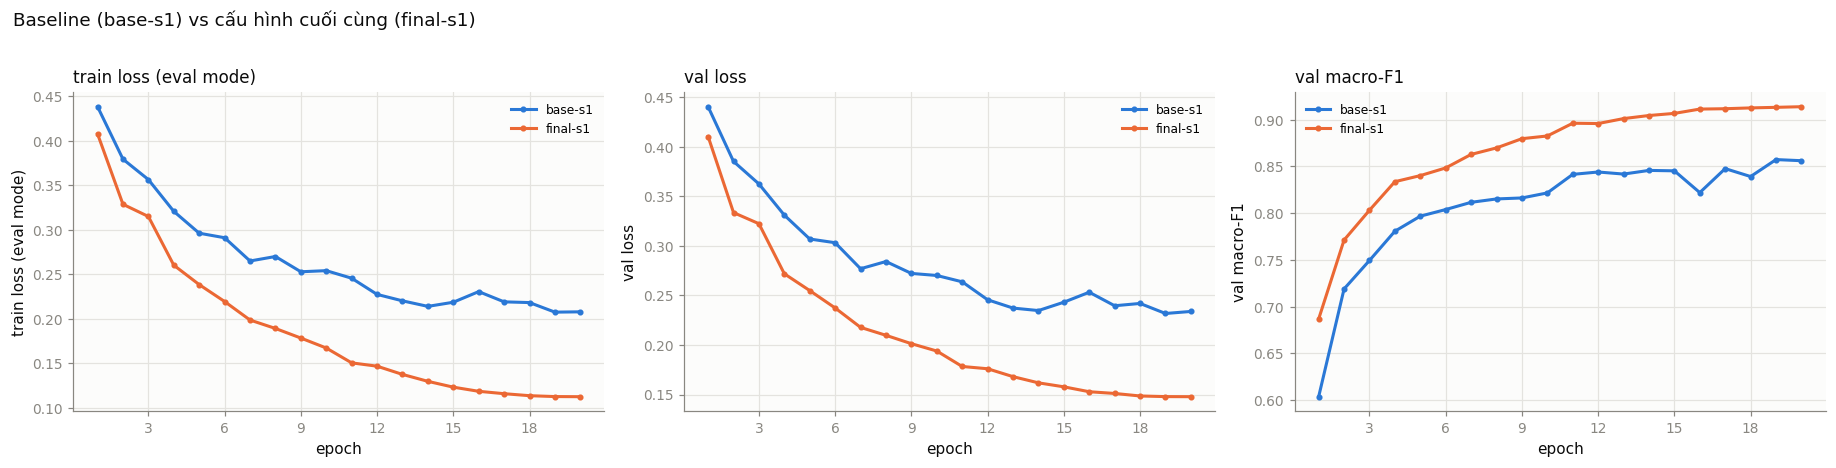

In [23]:
opt_candidates = [r for runs in opt_runs.values() for r in runs]
best_opt = max(opt_candidates, key=f1_of)
final_over = dict(optimizer=best_opt["cfg"]["optimizer"], lr=best_opt["cfg"]["lr"], weight_decay=best_opt["cfg"]["weight_decay"])
why = [f"optimizer={final_over['optimizer']}, lr={final_over['lr']:g}, wd={final_over['weight_decay']:g} (từ {best_opt['cfg']['exp_id']}, val macro-F1 {f1_of(best_opt):.4f})"]

def helps(r):                      # vượt trung bình baseline hơn ngưỡng nhiễu 2σ?
    return f1_of(r) - BASE_F1_MEAN > NOISE_F1

arch = max([hp_runs["hp-wide"], hp_runs["hp-deep"]], key=f1_of)
if helps(arch):
    final_over["hidden"] = arch["cfg"]["hidden"]; why.append(f"hidden={arch['cfg']['hidden']} (từ {arch['cfg']['exp_id']}, +{f1_of(arch) - BASE_F1_MEAN:.4f} > 2σ)")
else:
    why.append("giữ M-base (wide/deep không vượt 2σ)")
best_drop = max(drop_runs, key=f1_of)
if helps(best_drop):
    final_over["dropout"] = best_drop["cfg"]["dropout"]; why.append(f"dropout={best_drop['cfg']['dropout']:g} (+{f1_of(best_drop) - BASE_F1_MEAN:.4f} > 2σ)")
else:
    why.append(f"không dropout (tốt nhất là {best_drop['cfg']['exp_id']}: {f1_of(best_drop) - BASE_F1_MEAN:+.4f}, không vượt 2σ)")
if helps(hp_runs["hp-cosine"]):
    final_over["scheduler"] = "cosine"; why.append(f"lịch cosine (+{f1_of(hp_runs['hp-cosine']) - BASE_F1_MEAN:.4f} > 2σ)")
else:
    why.append(f"lr hằng (cosine: {f1_of(hp_runs['hp-cosine']) - BASE_F1_MEAN:+.4f}, không vượt 2σ)")
if BASE["summary"]["best_epoch"] == EPOCHS:
    final_over["epochs"] = 2 * EPOCHS; why.append(f"epochs={2 * EPOCHS} (base-s1 đạt best ở epoch cuối: chưa hội tụ)")
else:
    why.append(f"epochs={EPOCHS} (base-s1 đạt best ở epoch {BASE['summary']['best_epoch']})")
print("Cấu hình cuối cùng, chọn bằng val:"); [print("  -", w) for w in why]
FINAL_NOTE = "Cấu hình cuối, đổi NHIỀU yếu tố so với baseline, chọn bằng val: " + "; ".join(why)

FINAL_SEEDS = [1, 2, 3]
final_runs = [run(dict(exp_id=f"final-s{s}", group="final", seed=s, description=f"Cấu hình cuối cùng (tổ hợp chọn bằng val), seed {s}", **final_over),
                  note=FINAL_NOTE, need_state=(s == 1), verbose=(s == 1)) for s in FINAL_SEEDS]
FINAL = RESULTS["final-s1"]
ff1 = np.array([f1_of(r) for r in final_runs])
print(f"\nfinal  val macro-F1: {ff1.round(4)}  TB = {ff1.mean():.4f}  σ = {ff1.std(ddof=1):.4f}")
print(f"base   val macro-F1: TB = {BASE_F1_MEAN:.4f}  2σ = {NOISE_F1:.4f}   -> chênh TB = {ff1.mean() - BASE_F1_MEAN:+.4f}")
table([r["cfg"]["exp_id"] for r in base_runs + final_runs])
plot_compare([BASE, FINAL], ["train_loss", "val_loss", "val_macro_f1"], f"{FIG_DIR}/compare_final.png", "Baseline (base-s1) vs cấu hình cuối cùng (final-s1)")
display(Image(filename=f"{FIG_DIR}/final-s1.png")); display(Image(filename=f"{FIG_DIR}/compare_final.png"))

**Đối chiếu sau khi chạy — đúng về hướng và độ lớn, sai về nguyên nhân chính và về tính cộng dồn.** Tôi dự đoán lợi ích đến chủ yếu
từ mạng rộng hơn và huấn luyện lâu hơn; thực tế thành phần đóng góp lớn nhất là lịch cosine, còn số epoch không đổi.
- **Cấu hình được chọn (theo quy tắc ở trên, chỉ dùng val):** Adam, lr = 3e-3, wd = 0 (từ `opt-adam-lr0.003`, 0,8677) + `M-wide`
  (từ `hp-wide`, +0,0140 > 2σ) + lịch cosine (từ `hp-cosine`, +0,0340 > 2σ); **không** dropout (`drop-0.1` làm kém đi 0,0222);
  **giữ 20 epoch** vì `base-s1` đạt best ở epoch 19 chứ không phải epoch cuối, quy tắc tăng epoch không kích hoạt.
- **Kết quả val (3 seed):** macro-F1 = 0,9139 / 0,9122 / 0,9132 → TB **0,9131**, σ = 0,0008; accuracy TB 0,9426. So với TB baseline
  0,8607: **+0,0524**, gấp ~8,7 lần ngưỡng 2σ = 0,0060 → cải thiện có ý nghĩa, và ổn định giữa các seed.
- **Tính cộng dồn:** tổng lợi ích riêng lẻ là 0,0070 + 0,0140 + 0,0340 = 0,0550; tổ hợp đạt 0,0524, tức gần như cộng dồn (hụt 0,003) — trái với dự đoán "không cộng dồn hoàn toàn".
- **Đường cong:** train loss 0,1124, val loss 0,1479 ở epoch 20; khoảng cách val − train (0,036) lớn hơn baseline (0,026) và tăng dần,
  nhưng val loss vẫn giảm tới epoch cuối → mô hình bắt đầu quá khớp nhẹ, chưa tới mức cần dừng sớm.
- **Hạn chế:** `M-wide` và cosine được kiểm chứng trên SGD+momentum, còn tổ hợp dùng Adam; tôi không chạy phép loại bỏ từng thành phần
  (ablation) trên tổ hợp. Quy tắc epoch phụ thuộc một seed (best epoch 19 so với 20), nên việc giữ 20 epoch có phần may rủi; mô hình
  cuối vẫn đang cải thiện ở epoch 20, huấn luyện lâu hơn có thể tốt hơn nữa nhưng tôi không thử sau khi đã xem điểm eval.

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài

Từ đây mới dùng tập eval, và chỉ cho **hai** mô hình: `base-s1` và `final-s1` (trọng số của epoch có val loss thấp nhất). Dự đoán trên
toàn bộ eval ở chế độ `eval()` (FP32, không dropout), ghi CSV `row_id,pred`, chấm bằng `scripts/evaluate.py`. Không chỉnh gì sau khi thấy
điểm eval.

In [24]:
# Cấu hình cuối cùng -> file nộp predictions_eval.csv + eval_result.json
final_eval(FINAL["cfg"], FINAL, data, f"{OUT_DIR}/predictions_eval.csv")
print("===== final-s1 =====")
EVAL_FINAL = run_official_eval(f"{OUT_DIR}/predictions_eval.csv", f"{OUT_DIR}/eval_result.json", REPO_ROOT)

# Baseline -> chỉ lấy điểm (file dự đoán của baseline không nộp; kết quả lưu ở eval_result_baseline.json)
with tempfile.TemporaryDirectory() as tmp:
    final_eval(BASE["cfg"], BASE, data, f"{tmp}/pred_base.csv")
    print("===== base-s1 =====")
    EVAL_BASE = run_official_eval(f"{tmp}/pred_base.csv", f"{OUT_DIR}/eval_result_baseline.json", REPO_ROOT)

cmp_df = pd.DataFrame([
    dict(cấu_hình="base-s1", val_macro_f1=f1_of(BASE), eval_macro_f1=EVAL_BASE["macro_f1"], eval_acc=EVAL_BASE["accuracy"]),
    dict(cấu_hình="final-s1", val_macro_f1=f1_of(FINAL), eval_macro_f1=EVAL_FINAL["macro_f1"], eval_acc=EVAL_FINAL["accuracy"]),
]).set_index("cấu_hình")
print(cmp_df.to_string(float_format=lambda v: f"{v:.4f}"))
print(f"\ncải thiện eval macro-F1 = {EVAL_FINAL['macro_f1'] - EVAL_BASE['macro_f1']:+.4f}   (ngưỡng nhiễu 2σ của val macro-F1 baseline = {NOISE_F1:.4f})")
print(f"lệch val -> eval: base {EVAL_BASE['macro_f1'] - f1_of(BASE):+.4f}, final {EVAL_FINAL['macro_f1'] - f1_of(FINAL):+.4f}")

===== final-s1 =====
n_eval = 116203
accuracy = 0.9417
macro_f1 = 0.9158   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9436  0.9316  0.9376
  1    56661     0.9441  0.9555  0.9498
  2     7151     0.9415  0.9457  0.9436
  3      549     0.8910  0.8488  0.8694
  4     1899     0.8871  0.8441  0.8651
  5     3473     0.8981  0.8834  0.8907
  6     4102     0.9544  0.9542  0.9543

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  39469   2701     1    0    25     4   168
1   2166  54140    82    0   164    90    19
2      1    126  6763   38    13   210     0
3      0      0    52  466     0    31     0
4     28    242    13    0  1603    13     0
5      4    109   272   19     1  3068     0
6    159     28     0    0     1     0  3914

đã ghi /content/K4-Track4-Day1-Neuralnetwork/submission_MSSV/eval_result.json

===== base-s1 =====
n_eval = 116203
accuracy = 0.9089
macro_f1 = 0.8565   <- chỉ số chính

lớp  suppor

                   tên  support  precision  recall     f1  f1_baseline
cls                                                                   
0           Spruce/Fir    42368     0.9436  0.9316 0.9376       0.9044
1       Lodgepole Pine    56661     0.9441  0.9555 0.9498       0.9263
2       Ponderosa Pine     7151     0.9415  0.9457 0.9436       0.8943
3    Cottonwood/Willow      549     0.8910  0.8488 0.8694       0.8015
4                Aspen     1899     0.8871  0.8441 0.8651       0.7595
5          Douglas-fir     3473     0.8981  0.8834 0.8907       0.8089
6            Krummholz     4102     0.9544  0.9542 0.9543       0.9002

ma trận nhầm lẫn final-s1 (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  39469   2701     1    0    25     4   168
1   2166  54140    82    0   164    90    19
2      1    126  6763   38    13   210     0
3      0      0    52  466     0    31     0
4     28    242    13    0  1603    13     0
5      4    109   272   19     1  

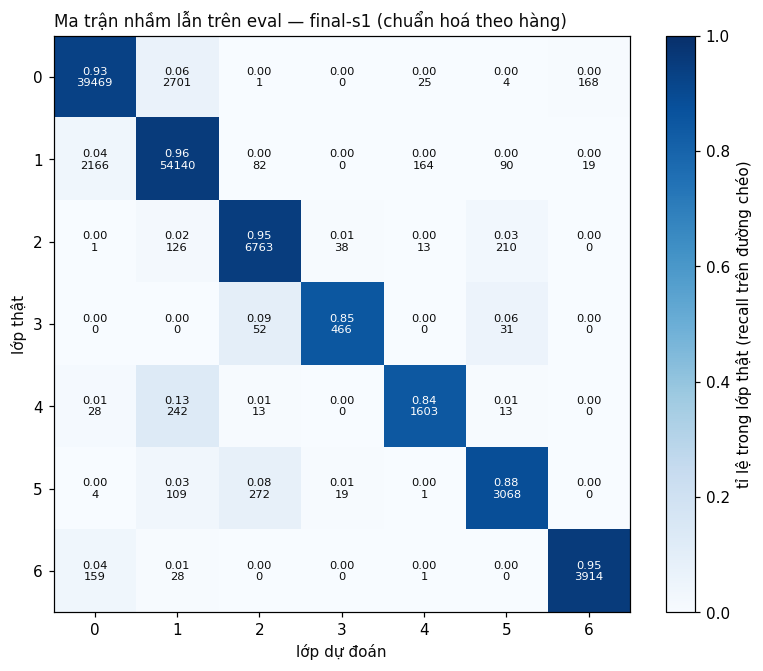

In [25]:
# Phân tích lỗi theo lớp trên eval (số lấy từ eval_result.json)
CLASS_NAMES = ["Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine", "Cottonwood/Willow", "Aspen", "Douglas-fir", "Krummholz"]
pc = pd.DataFrame(EVAL_FINAL["per_class"]).set_index("cls")
pc.insert(0, "tên", CLASS_NAMES)
pc["f1_baseline"] = [d["f1"] for d in EVAL_BASE["per_class"]]
print(pc.to_string(float_format=lambda v: f"{v:.4f}"))

cm = np.array(EVAL_FINAL["confusion_matrix"])
print("\nma trận nhầm lẫn final-s1 (hàng = thật, cột = dự đoán):"); print(pd.DataFrame(cm).to_string())
print("\nVới mỗi lớp thật: lớp bị nhầm sang nhiều nhất")
for c in range(7):
    off = cm[c].copy(); off[c] = 0; j = int(off.argmax())
    print(f"  lớp {c} ({CLASS_NAMES[c]:17s}) support {cm[c].sum():6d}: {off[j]:5d} mẫu ({off[j] / cm[c].sum():6.2%}) bị đoán thành lớp {j} ({CLASS_NAMES[j]})")
hard = int(pc["f1"].idxmin())
fp_src = cm[:, hard].copy(); fp_src[hard] = 0
print(f"\nLớp khó nhất: lớp {hard} ({CLASS_NAMES[hard]}), F1 = {pc.loc[hard, 'f1']:.4f}; dương tính giả đến chủ yếu từ lớp {int(fp_src.argmax())} ({fp_src.max()} mẫu)")
plot_confusion(cm, f"{FIG_DIR}/eval_confusion_final.png", "Ma trận nhầm lẫn trên eval — final-s1 (chuẩn hoá theo hàng)")
display(Image(filename=f"{FIG_DIR}/eval_confusion_final.png"))

**Phân tích lỗi trên eval (số từ `eval_result.json`, mô hình `final-s1`):**
- **Điểm:** eval macro-F1 **0,9158**, accuracy 0,9417; baseline `base-s1`: 0,8565 / 0,9089 → cải thiện **+0,0593** macro-F1, gấp ~10
  lần ngưỡng nhiễu 2σ = 0,0060 (đo trên val). Val và eval rất gần nhau: lệch −0,0009 (baseline) và +0,0019 (final).
- **Lớp khó nhất: lớp 4 (Aspen), F1 = 0,8651** (precision 0,8871, recall 0,8441). 242/1 899 mẫu Aspen (12,7%) bị đoán thành lớp 1
  (Lodgepole Pine), và dương tính giả của Aspen cũng chủ yếu đến từ lớp 1 (164 mẫu). Sát sau là **lớp 3 (Cottonwood/Willow), F1 =
  0,8694**: 52/549 mẫu (9,5%) bị đoán thành lớp 2 (Ponderosa Pine), 31 mẫu thành lớp 5.
- **Cặp nhầm lẫn theo cụm:** {2, 3, 5} nhầm lẫn nhau (lớp 5 → lớp 2: 272 mẫu, 7,8%; lớp 2 → lớp 5: 210 mẫu) và {0, 1, 4, 6}
  nhầm lẫn nhau (lớp 0 → 1: 2 701 mẫu, 6,4%; lớp 1 → 0: 2 166 mẫu, 3,8%; lớp 6 → 0: 159 mẫu). Giữa hai cụm gần như không nhầm.
- **Lý giải:** (1) *Số mẫu*: lớp 4 chỉ chiếm 1,6% và lớp 3 chỉ 0,5% dữ liệu; CE không trọng số nên tổng loss do lớp 0 và 1 (85% dữ
  liệu) chi phối, biên quyết định bị đẩy về phía có lợi cho lớp lớn — recall của lớp 4 (0,844) thấp hơn precision (0,887). (2) *Đặc
  trưng*: cấu trúc hai cụm cho thấy mô hình tách tốt theo nhóm điều kiện địa hình nhưng khó tách trong cùng nhóm; tôi **phỏng đoán**
  (chưa kiểm chứng trên dữ liệu) rằng các lớp cùng cụm chia sẻ dải độ cao và loại đất.
- **So với baseline theo lớp:** F1 tăng nhiều nhất ở chính các lớp hiếm: lớp 4 0,7595 → 0,8651 (+0,106), lớp 5 0,8089 → 0,8907
  (+0,082), lớp 3 0,8015 → 0,8694 (+0,068); lớp lớn tăng ít hơn (lớp 1: +0,024). Macro-F1 tăng chủ yếu nhờ lớp hiếm.
- **Sẽ thử tiếp:** CE có trọng số theo lớp (hoặc lấy mẫu cân bằng) để tăng recall lớp 3 và 4; chọn bằng val, không dùng eval.

In [26]:
# Bảng experiments.xlsx: mỗi thí nghiệm đã chạy một dòng, đọc lại từ results/<exp_id>.json
SUMMARY_NOTES = {   # nhận xét ngắn cho sheet Summary (viết sau khi có kết quả)
    'baseline': 'SGD+momentum lr=0.3 (chọn bằng val). 3 seed: val macro-F1 TB 0.8607, σ 0.0030, 2σ 0.0060. Train/val loss còn giảm: chưa khớp hết.',
    'loss': 'MSE kém CE 0.088 macro-F1 (≈15×2σ): grad_norm nhỏ hơn ~5 lần, chưa hội tụ sau 20 epoch. Chỉ so acc/macro-F1, không so loss.',
    'optimizer': 'Ở lr tốt nhất: Adam 0.8677 ≳ AdamW 0.8646 ≈ SGD+momentum 0.8573 > SGD 0.8344. Adam hơn TB baseline 0.0070, sát ngưỡng 2σ. AdamW(wd=0) ≡ Adam.',
    'hparam': 'Cosine +0.034 và M-wide +0.014 vượt 2σ. Batch 128, M-deep, wd 1e-4 đều kém hơn ở lr cố định. Batch 2048 với lr×4 (không warmup) sụp về lớp đa số.',
    'dropout': 'Mô hình chưa quá khớp nên dropout chỉ làm kém đi: q=0.1/0.3/0.5 → -0.022/-0.078/-0.282; khoảng cách val-train thu hẹp vì train loss tăng.',
    'clipping': 'lr thường: clip c=0.35 (66.6% bước) không đổi kết quả. lr×10: không clip → sụp; c=0.35 không cứu (0.19); c=0.035 (giữ lr·c) cứu hoàn toàn (0.8549).',
    'amp': 'T4: FP16 chậm hơn FP32 38%, BF16 chậm hơn 20% (mạng quá nhỏ). FP16 ngang FP32; BF16 -0.0087 (sát ngưỡng, 1 seed). peak_mem không giảm.',
    'init': 'zeros: chỉ học bias lớp ra → đoán lớp đa số (0.0936). normal/default trong nhiễu, xavier -0.0105. Mạng 3 lớp quá nông để phân biệt He/Xavier.',
    'final': 'Adam lr=3e-3 + M-wide + cosine, 20 epoch (chọn bằng val). 3 seed: val macro-F1 0.9131 ± 0.0008 (+0.0524). Eval final-s1: 0.9158 (baseline 0.8565).',
}
EVAL_SCORES = {"base-s1": EVAL_BASE, "final-s1": EVAL_FINAL}       # điểm eval CHỈ cho baseline và cấu hình cuối cùng
rows = sort_rows([to_row(load_result(i, RES_DIR), EVAL_SCORES.get(i), NOTES.get(i, "")) for i in RESULTS])
seed_ids = [f"base-s{s}" for s in BASE_SEEDS]
write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx",
           seed_ids=seed_ids, summary_notes=SUMMARY_NOTES)

figs = {f[:-4] for f in os.listdir(FIG_DIR) if f.endswith(".png") and not f.startswith(("compare_", "check_", "eval_"))}
assert figs == set(RESULTS), (figs ^ set(RESULTS))     # số ảnh <exp_id>.png = số dòng bảng, tên trùng exp_id
print(f"đã ghi {OUT_DIR}/experiments.xlsx: {len(rows)} dòng, {len(figs)} ảnh <exp_id>.png; sheet Seeds = {seed_ids}")
print(pd.Series([r['group'] for r in rows]).value_counts().reindex(["baseline","loss","optimizer","hparam","dropout","clipping","amp","init","final"]).to_string())
if AMP_FAIL: print("AMP không chạy được:", AMP_FAIL)
print(f"\nTổng thời gian huấn luyện (cộng các lần chạy): {sum(r['summary']['total_time_s'] for r in RESULTS.values()) / 60:.1f} phút")

đã ghi ../experiments.xlsx: 44 dòng, 44 ảnh <exp_id>.png; sheet Seeds = ['base-s1', 'base-s2', 'base-s3']
baseline      3
loss          1
optimizer    17
hparam        7
dropout       3
clipping      4
amp           2
init          4
final         3

Tổng thời gian huấn luyện (cộng các lần chạy): 21.1 phút


**Lưu ý về `experiments.xlsx`:** `openpyxl` chỉ ghi giá trị và giữ nguyên công thức, không tính công thức. Mở file bằng Excel/LibreOffice
rồi lưu lại để các ô xám (`step0_gap_vs_lnC`, `gap_val_minus_train`, `delta_val_f1_vs_base`, `beyond_noise`) và hai sheet `Seeds`,
`Summary` hiện giá trị.

In [27]:
# (Chỉ Colab) nén toàn bộ thư mục nộp (results, figures, bảng, dự đoán, code) và tải về máy
if IN_COLAB:
    import shutil
    from google.colab import files
    sub_dir = os.path.abspath(OUT_DIR)
    shutil.rmtree(os.path.join(sub_dir, "code", "__pycache__"), ignore_errors=True)
    zip_path = shutil.make_archive("/content/colab_output", "zip", root_dir=os.path.dirname(sub_dir), base_dir=os.path.basename(sub_dir))
    print("đã nén:", zip_path); files.download(zip_path)

đã nén: /content/colab_output.zip
